# 🎨 Módulo 3 — Visualização de Dados
## Livro Didático Aplicado (Híbrido + Storytelling + Comunicação Visual)

- 🔵 **Conteúdo oficial do módulo 3 (IBM)**
- 🟣 **Conteúdo expandido (Livro Didático)**
- 🟠 **Conteúdo avançado (Opcional, matemático e perceptual)**

Este notebook é uma evolução natural do Módulo 2.
Agora, vamos aprender **como transformar dados em imagens que revelam padrões, histórias e decisões**.

Você pode:
- seguir só o que é 🔵 (curso),
- mergulhar no 🟣 (livro didático),
- ou abrir o 🟠 (avançado) quando quiser ir mais fundo.

Este módulo combina:
- estatística,
- design de informação,
- percepção visual,
- storytelling,
- e boas práticas profissionais de Data Visualization.

Prepare-se: este é um dos módulos mais importantes de toda a formação.

<a id="indice"></a>
# 📚 Índice

1. [Introdução: por que visualizar dados?](#visualizar-dados)
2. [Fundamentos da visualização](#visualizacao)
3. [Ferramentas em Python](#ferramentas)
4. [Gráficos para variáveis categóricas](#categoricas)
5. [Gráficos para variáveis numéricas](#numericas)
6. [Relações entre variáveis](#variaveis)
7. [Storytelling com dados](#7-storytelling-com-dados)
8. [Aplicações com teaching ratings](#teaching-ratings)
9. [Exercícios guiados](#exercicios)
10. [Diagramas conceituais](#diagramas)
11. [Apêndice matemático avançado](#apendice)
12. [Encerramento](#12-encerramento)

---
# 0. Setup — bibliotecas e dados

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_theme(context="notebook", style="whitegrid")

🔵 **Dataset oficial do curso**

Usaremos novamente o dataset *teaching ratings*, pois ele:
- contém variáveis categóricas e numéricas,
- permite análises multivariadas,
- é perfeito para demonstrar visualizações estatísticas.

In [ ]:
ratings_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ST0151EN-SkillsNetwork/labs/teachingratings.csv"
ratings_df = pd.read_csv(ratings_url)
ratings_df.to_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/teachingratings.csv", index=False)
ratings_df.head()

In [2]:
# base de dados local
ratings_df = pd.read_csv("/home/moacir/projects/ml/IBM/statistics/data/raw/teachingratings.csv")

<a id="visualizar-dados"></a>
[↑ - Índice](#indice)
# 1. Introdução: por que visualizar dados?

A visualização de dados é uma das ferramentas mais poderosas da estatística moderna.
Ela permite transformar **números** em **formas**, **padrões**, **tendências** e **histórias**.

Antes de modelos, antes de testes, antes de algoritmos — **visualizamos**.

<br>

> “The greatest value of a picture is when it forces us to notice what we never expected to see.”  
> — *John Tukey*, pai da análise exploratória de dados (EDA)  

<br>

A visualização é o primeiro passo para:
- entender a estrutura dos dados,
- identificar padrões,
- detectar outliers,
- comparar grupos,
- comunicar achados,
- e tomar decisões.

Ela é a ponte entre:
- **estatística** (o rigor),
- **design** (a forma),
- **percepção humana** (a interpretação),
- **comunicação** (a mensagem).

<br>


## 🟣 1.1 A história da visualização de dados

A visualização é mais antiga do que imaginamos.

- **William Playfair (1786)**  
  Criou o gráfico de barras, o gráfico de linhas e o gráfico de pizza.

- **Florence Nightingale (1858)**  
  Criou o *coxcomb chart* para mostrar que mais soldados morriam por infecções do que por batalha.

- **John Tukey (1977)**  
  Formalizou a Análise Exploratória de Dados (EDA) e popularizou boxplots.

- **Edward Tufte (1983–2006)**  
  Revolucionou o design de informação com princípios como:
  - “maximize data-ink ratio” → maximizar a relação dados-tinta
  - “above all else, show the data” → Acima de tudo, mostrar os dados

- **Stephen Few (2004–2012)**  
  Criou padrões modernos para dashboards e comunicação visual.

- **Andrew Abela (2006)**  
  Criou o *Extreme Presentation Method*, que mapeia **tipos de gráficos** para **tipos de perguntas**.

<br>

- **Hoje, visualização é parte essencial de**:
  - ciência de dados,
  - estatística,
  - business intelligence,
  - machine learning,
  - jornalismo de dados,
  - e tomada de decisão corporativa.

## 🟣 1.2 Por que visualizar antes de analisar?

> A visualização é o equivalente estatístico de “olhar para o problema”.

Antes de calcular médias, variâncias ou ajustar modelos, precisamos **ver**:

- A distribuição é simétrica ou assimétrica?  
- Existem outliers?  
- Há grupos distintos?  
- A relação entre duas variáveis é linear?  
- Há padrões escondidos?  

Muitas vezes, um gráfico revela em segundos o que números levariam horas para explicar.

## 🟣 1.3 O papel da percepção visual

> A visualização funciona porque o cérebro humano é excepcional em detectar padrões visuais.

**Processos pré-atentivos**
- São percepções automáticas, instantâneas, como:
    - cor,
    - forma,
    - tamanho,
    - orientação,
    - posição.

- Esses elementos ajudam a destacar:
    - grupos,
    - tendências,
    - anomalias,
    - relações.

<br>

**Leis da Gestalt**
- A mente organiza elementos visuais segundo princípios como:
    - proximidade,
    - similaridade,
    - continuidade,
    - fechamento.

Esses princípios explicam por que certos gráficos funcionam melhor do que outros.

<br>

🟠 **Conteúdo avançado (opcional) — percepção visual e estatística**

- A percepção humana é otimizada para:
    - detectar **diferenças relativas**, não absolutas;
    - perceber **tendências**, não valores exatos;
    - identificar **formas**, não tabelas;
    - comparar **posições**, não áreas.

- Isso explica por que:
    - gráficos de barras (comparação por altura) são superiores a gráficos de pizza (comparação por área);
    - gráficos de linhas são ideais para séries temporais;
    - scatterplots são essenciais para relações entre variáveis contínuas.

<br>

- Estudos clássicos de **Cleveland & McGill (1984)** demonstraram empiricamente que:
    1. Comparar **posições** é mais preciso que comparar **comprimentos**.  
    2. Comparar **comprimentos** é mais preciso que comparar **áreas**.  
    3. Comparar **áreas** é mais preciso que comparar **ângulos**.  

> Isso fundamenta a escolha de gráficos em estatística moderna.

## 🟣 1.4 Visualização como comunicação

Um gráfico não é apenas uma ferramenta analítica — é uma **mensagem**.

Um bom gráfico:
- responde uma pergunta,
- destaca o que importa,
- remove o que distrai,
- guia o olhar,
- conta uma história.

Um gráfico ruim:
- confunde,
- distorce,
- esconde padrões,
- engana,
- atrapalha decisões.

Visualizar dados é, portanto, um ato de **comunicação científica**.

## 🟣 1.5 O triângulo da visualização  
> ### (Extreme Presentation Method – Chart Selection Framework)

O framework criado por **Andrew Abela (2006)** — conhecido como **Extreme Presentation Method** — organiza todos os tipos de gráficos a partir de **quatro perguntas fundamentais**:

<br>

| Chart Chooser | Perguntas |
|-|-|
| **1. Comparação** | - Qual grupo é maior? <br> - Quem tem maior média? |
| **2. Composição** | - Como algo se divide em partes? <br> - Como a composição muda ao longo do tempo? |
| **3. Distribuição** | - Como os valores se espalham? <br> - Há assimetria? Outliers? |
| **4. Relação** | - Como duas variáveis se relacionam? <br> - Há correlação? Tendência? |

<br>

Esses 4 tipos de perguntas formam o que muitos autores chamam de **“Triângulo da Visualização”**, pois representam os três vértices clássicos (Comparação, Composição, Distribuição) e o eixo adicional (Relação).  
Esse framework é a base moderna para escolher o gráfico certo.

<br>

### 🖼️ Representação visual do Chart Chooser (Abela, 2006)

Abaixo estão duas versões do diagrama original, incluídas no projeto:

<p float="left">
  <img src="../../images/tipoGraficos_1.jpg" alt="Chart Chooser 1" width="45%" />
  <img src="../../images/tipoGraficos_3.jpg" alt="Chart Chooser 3" width="45%" />
</p>

<br>

> **Essas imagens mostram exatamente como o método organiza os gráficos**  
de acordo com o tipo de pergunta que queremos responder.

<br>

- 🟣 **Por que isso importa?**
    - Ajuda a **escolher o gráfico certo** com base na pergunta, não no gosto pessoal.  
    - Evita erros comuns (como usar pizza para comparar muitos grupos).  
    - Cria consistência visual ao longo do projeto.  
    - Conecta visualização com **estatística**, **design** e **storytelling**.

Este triângulo será usado ao longo de todo o módulo para justificar  
a escolha de cada gráfico.


## 🟣 1.6 O que vamos aprender neste módulo

Neste módulo, você aprenderá:

- como escolher o gráfico certo para cada tipo de variável,
- como usar matplotlib e seaborn com precisão,
- como interpretar gráficos estatísticos,
- como criar visualizações multivariadas,
- como comunicar achados com clareza,
- como evitar erros comuns,
- como aplicar storytelling visual,
- como usar cores, formas e escalas de forma inteligente.

E tudo isso usando o dataset *teaching ratings* como laboratório prático.

<br>

---

<a id="visualizacao"></a>
[↑ - Índice](#indice)
# 2. Fundamentos da visualização

A visualização de dados é uma disciplina que combina:
- estatística,
- design de informação,
- percepção visual,
- comunicação científica.

Antes de escolher um gráfico, precisamos entender:
- **que tipo de variável temos**,  
- **que pergunta queremos responder**,  
- **como o cérebro humano interpreta formas, cores e posições**.

Esta seção estabelece os fundamentos que guiarão todas as visualizações do módulo.

## 🟣 2.1 Tipos de variáveis → tipos de gráficos

> A escolha do gráfico depende diretamente do tipo de variável.

| Tipos | Variáveis | Gráficos recomendados |
|-|-|-|
| **Variáveis categóricas** | - gênero (male/female) <br> - tenure (yes/no) <br> - division (upper/lower) | - barplot <br> - countplot <br> - stacked bar <br> - pie chart (com cautela) <br> - catplot (com hue, col, row) |
| **Variáveis numéricas** | - idade <br> - beleza <br> - avaliação <br> - número de alunos | - histograma <br> - KDE (densidade) <br> - boxplot <br> - violinplot <br> - ECDF (avançado) |
| **Numérica × Numérica** | Relações entre variáveis | - scatterplot <br> - bubble chart <br> - regplot <br> - jointplot |
| **Numérica × Categórica** | Relações entre variáveis | - boxplot <br> - violinplot <br> - swarmplot <br> |
| **Categórica × Categórica** | Relações entre variáveis | - heatmap de contingência <br> - stacked bar <br> - |

<br>

- **Essa taxonomia é essencial para evitar erros comuns como**:
    - usar gráfico de pizza para comparar muitos grupos,
    - usar gráfico de barras para variáveis contínuas,
    - usar scatterplot para variáveis categóricas.

## 🟣 2.2 O Método de Apresentação Extrema (Andrew Abela)

Andrew Abela propôs um framework simples e poderoso:

> **Escolha o gráfico com base na pergunta que você quer responder.**

Ele divide as perguntas em quatro categorias:

<br>

| Chart Chooser | Perguntas | Gráficos |
|-|-|-|
| **1. Comparação** | - Qual grupo é maior? <br> - Quem tem maior valor? <br> - Quem tem maior média? | - barplot <br> - column chart <br> - line chart (se houver tempo) |
| **2. Composição** | - Como algo se divide em partes? <br> - Como a composição muda ao longo do tempo? | - pie chart (estático) <br> - stacked bar <br> -stacked area |
| **3. Distribuição** | - Como os valores se espalham? <br> - Há assimetria? Outliers? | - histograma <br> - KDE <br> - boxplot <br> - violinplot |
| **4. Relação** | - Como duas variáveis se relacionam? <br> - Há correlação? Tendência? | - scatterplot <br> - bubble chart <br> pairplot |


<br>


> Este método será aplicado repetidamente ao longo do módulo.

## 🟣 2.3 Boas práticas de design (Tufte, Few, Cleveland)

>   - **Visualização é comunicação,**  
>       - **... e comunicação exige clareza.**

<br>

<u>**Aqui estão princípios clássicos:**</u>

1. **Maximize o “data-ink ratio” (Tufte)**
    - Remova elementos desnecessários.
    - Evite bordas pesadas, sombras, 3D, gradientes.

2. **Mostre os dados acima de tudo (Tufte)**
    - Não esconda padrões.
    - Não distorça escalas.

3. **Use cores com propósito (Few)**
    - Cores qualitativas → categorias  
    - Cores sequenciais → intensidade  
    - Cores divergentes → desvios da média

4. **Priorize posição sobre área (Cleveland & McGill)**
    - Comparações por posição são mais precisas que por área.
    - Por isso, barras > pizza.

5. **Evite chartjunk**
    - Efeitos visuais que não adicionam informação.

6. **Use títulos informativos**
    - “Avaliação média por gênero” é melhor que “Gráfico 1”.

7. **Mantenha consistência**
    - Mesmas cores para mesmas categorias.
    - Mesma escala quando comparável.

<br>

### 🟠 Conteúdo avançado (opcional) — princípios perceptuais formais

> A percepção humana segue leis matemáticas e cognitivas:

**Lei de Weber–Fechner**  
- A percepção de diferença é proporcional ao logaritmo da intensidade.
- Isso explica por que:
    - diferenças pequenas em barras são percebidas,
    - diferenças pequenas em áreas não são.

<br>

**Teoria da Informação (Shannon)**
- Um gráfico eficaz reduz entropia:
    - remove ruído,
    - destaca sinal.

<br>

**Teoria da Gestalt**
- proximidade → agrupamento  
- similaridade → categorias  
- continuidade → tendência  
- fechamento → completude  

<br>

> Esses princípios explicam por que certos gráficos “funcionam” intuitivamente.

<br>

## 🟣 2.4 Erros comuns em visualização

**Aqui estão erros que você deve evitar:**

- ❌ **Usar gráfico de pizza para comparar muitos grupos** → Difícil de comparar ângulos.
- ❌ **Usar 3D sem necessidade** → Distorce percepção.
- ❌ **Usar cores aleatórias** → Cores devem comunicar, não decorar.
- ❌ **Escalas quebradas sem aviso** → Pode manipular interpretação.
- ❌ **Usar gráfico de barras para variáveis contínuas** → Histograma é mais adequado.
- ❌ **Não rotular eixos** → Sem contexto, o gráfico perde sentido.

## 🟣 2.5 Exemplo prático: comparação de categorias

> Vamos começar com um exemplo simples usando o dataset *teaching ratings*.

Pergunta:  
**Quantos cursos foram ministrados por instrutores homens e mulheres?**

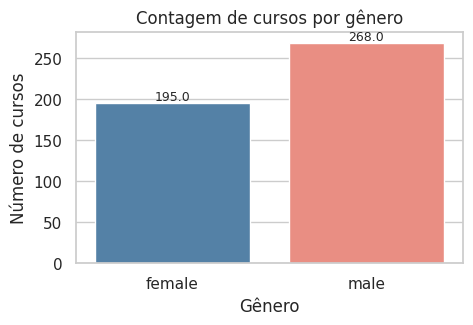

In [15]:
plt.figure(figsize=(5, 3))
ax = sns.countplot(x="gender", hue="gender", data=ratings_df, palette=["steelblue", "salmon"])
plt.title("Contagem de cursos por gênero")
plt.xlabel("Gênero")
plt.ylabel("Número de cursos")
# adicionar os valores acima das barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(text=str(height), xy=(p.get_x() + p.get_width() / 2 , height), ha='center', va='bottom', fontsize=9)
plt.show()

🟣 **Interpretação**

- O gráfico mostra que instrutores homens ministraram mais cursos.
- Este é um gráfico de **comparação**.
- A escolha do gráfico **(countplot)** é adequada porque:
  - a variável é categórica,
  - queremos comparar frequências,
  - barras são superiores a pizza para esse tipo de comparação.

<br>

## 🟣 2.6 Exemplo prático: distribuição de uma variável numérica

Pergunta:  
**Como os valores de `beauty` se distribuem?**

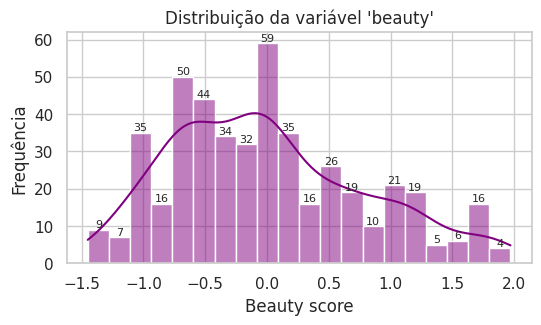

In [14]:
counts, bin_edges = np.histogram(ratings_df["beauty"], bins=20)
plt.figure(figsize=(6, 3))
ax = sns.histplot(ratings_df["beauty"], bins=20, kde=True, color="purple")
plt.title("Distribuição da variável 'beauty'"); plt.xlabel("Beauty score"); plt.ylabel("Frequência")
# adicionar os valores acima das barras
for count, patch in zip(counts, ax.patches):
    if count > 0:
        plt.text(patch.get_x() + patch.get_width() / 2, patch.get_height(), int(count), ha="center", va="bottom", fontsize=8)
plt.show()

🟣 **Interpretação visual de `beauty` como variável padronizada**

- A variável `beauty` já vem padronizada no conjunto de dados. Isso significa que ela está expressa em **z‑scores**, onde:
    - A distribuição é aproximadamente simétrica.
    - **0** representa a média,
    - valores **positivos** indicam beleza acima da média,
    - valores **negativos** indicam beleza abaixo da média,
    - **1 unidade** corresponde a **1 desvio padrão**.
    - O KDE (curva suave) ajuda a visualizar a forma da distribuição.

<br>

- Visualmente, isso coloca `beauty` em um eixo comum e comparável:

    ~~~text
    -2      -1       0       +1       +2
    |-------|-------|-------|--------|
      raros  poucos  muitos   poucos  raros
    ~~~

- Interpretação prática:
    - `beauty = +1.0` → 1 desvio padrão acima da média (acima do usual),
    - `beauty = -0.5` → meio desvio padrão abaixo da média (ligeiramente abaixo),
    - `beauty > +2` → valores raros, indicando casos muito acima da média.

- Essa leitura será importante nos gráficos a seguir, especialmente ao analisar:
    - dispersão,
    - densidade,
    - valores extremos,
    - e relações entre `beauty` e outras variáveis.

<br>

>A padronização permite comparar `beauty` com outras variáveis em escalas diferentes, mantendo a interpretação geométrica clara: **distância em relação ao centro**.


<br>

---

<a id="ferramentas"></a>
[↑ - Índice](#indice)
# 3. Ferramentas em Python

Para criar visualizações profissionais, usaremos duas bibliotecas principais:

- **matplotlib** → a base de tudo  
- **seaborn** → camada de alto nível, mais bonita e mais fácil de usar

Ambas são amplamente utilizadas em:
- ciência de dados,
- estatística,
- machine learning,
- dashboards,
- relatórios corporativos.

## 🔵 3.1 matplotlib — a base da visualização em Python

O `matplotlib` é a biblioteca fundamental de gráficos em Python.
Ele oferece controle total sobre:
- figuras,
- eixos,
- cores,
- estilos,
- anotações,
- escalas.

É poderoso, mas verboso.

Exemplo simples:

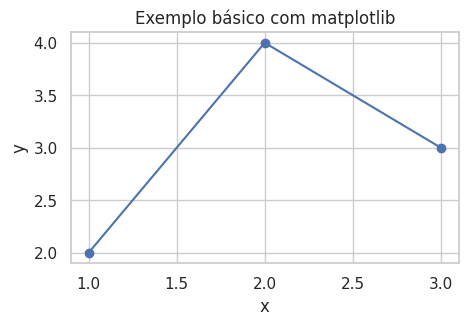

In [16]:
plt.figure(figsize=(5, 3))
plt.plot([1, 2, 3], [2, 4, 3], marker="o")
plt.title("Exemplo básico com matplotlib")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

🟣 **Interpretação**
- `matplotlib` exige mais código,
- mas permite personalização completa,
- e é a base sobre a qual o seaborn constrói seus gráficos.

## 🔵 3.2 seaborn — visualizações estatísticas de alto nível

O `seaborn` é construído sobre o `matplotlib`, mas:
- é mais bonito,
- mais simples,
- mais inteligente,
- e mais adequado para estatística.

Ele entende:
- DataFrames,
- variáveis categóricas,
- variáveis numéricas,
- relações estatísticas.

Exemplo:

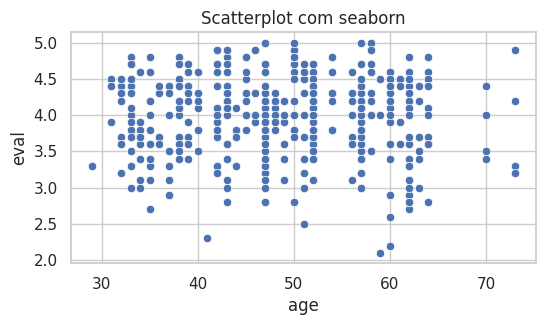

In [19]:
plt.figure(figsize=(6, 3))
sns.scatterplot(x="age", y="eval", data=ratings_df)
plt.title("Scatterplot com seaborn")
plt.show()

🟣 **Por que seaborn é ideal para estatística?**
- Ele aplica estilos automaticamente.
- Ele escolhe paletas adequadas.
- Ele entende tipos de variáveis.
- Ele cria gráficos estatísticos com uma linha de código.

<br>

- **Exemplos:**

    | Código | Gráfico |
    |-|-|
    | - `sns.histplot()` | → histogramas |
    | - `sns.boxplot()` | → boxplots |
    | - `sns.scatterplot()` | → dispersão |
    | - `sns.catplot()` | → gráficos categóricos |
    | - `sns.relplot()` | → relações multivariadas |

## 🟣 3.3 Estilos e temas

- O seaborn oferece temas prontos:
    - `"whitegrid"` (padrão estatístico)
    - `"darkgrid"`
    - `"white"`
    - `"dark"`
    - `"ticks"`

Exemplo:

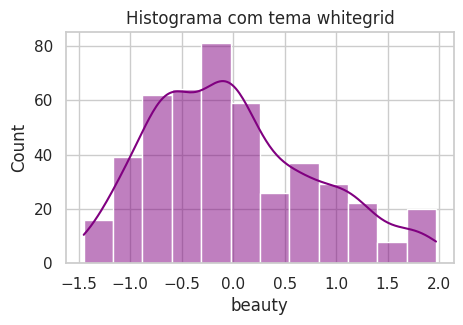

In [26]:
sns.set_theme(style="whitegrid", context="notebook")

plt.figure(figsize=(5, 3))
sns.histplot(ratings_df["beauty"], kde=True, color="purple")
plt.title("Histograma com tema whitegrid")
plt.show()

## 🟣 3.4 Paletas de cores

Cores são fundamentais para comunicação visual.

- **Paletas qualitativas (categorias)**
    - `"Set2"`
    - `"Paired"`
    - `"Accent"`

- **Paletas sequenciais (intensidade)**
    - `"Blues"`
    - `"Greens"`
    - `"Purples"`

- **Paletas divergentes (acima/abaixo da média)**
    - `"coolwarm"`
    - `"RdBu"`
    - `"Spectral"`

**Exemplo:**

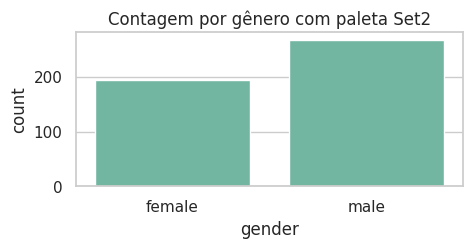

In [40]:
plt.figure(figsize=(5, 2))
sns.set_palette("Set2")
sns.countplot(x="gender", data=ratings_df)
plt.title("Contagem por gênero com paleta Set2")
plt.show()

## 🟣 3.5 Boas práticas de código para visualização

- ✔️ **Sempre defina `figsize`** → Para garantir legibilidade.
- ✔️ **Sempre coloque `title`, `xlabel`, `ylabel`** → Comunicação clara importa.
- ✔️ **Use paletas consistentes → Mesmas categorias** → mesmas cores.
- ✔️ **Evite gráficos 3D** → Distorcem percepção.
- ✔️ **Prefira seaborn para estatística** → Mais limpo, mais rápido, mais bonito.

<br>

### 🟠 Conteúdo avançado (opcional) — anatomia de uma figura matplotlib

- **Uma figura matplotlib é composta por**:
    - **Figure** → o “canvas”
    - **Axes** → os gráficos dentro da figura
    - **Axis** → eixos x e y
    - **Artists** → tudo que aparece (linhas, textos, marcadores)

<br>

- **Estrutura**  →  $ \text{Figure} \supset \text{Axes} \supset \text{Axis} \supset \text{Artists} $

<br>

- **Isso permite criar**:
    - múltiplos gráficos na mesma figura,
    - layouts complexos,
    - dashboards estáticos.

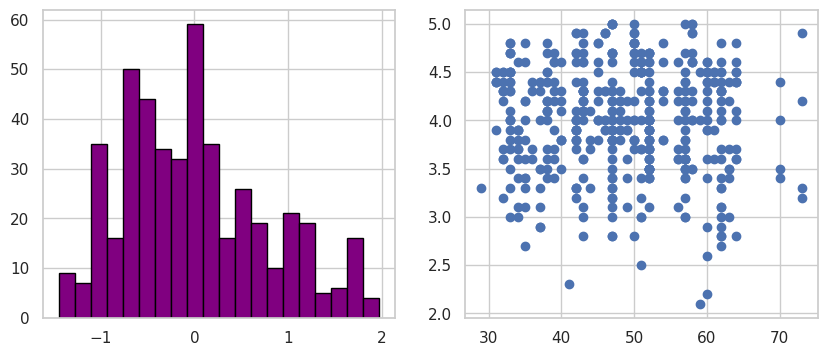

In [55]:
# Exemplo avançado:

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].hist(data=ratings_df, x="beauty", bins=20, color="purple", edgecolor="black")
ax[1].scatter(x=ratings_df["age"], y=ratings_df["eval"]);


<a id="categoricas"></a>
[↑ - Índice](#indice)
# 4. Gráficos para variáveis categóricas


Variáveis categóricas representam **grupos**, **categorias**, **classes**.
- Exemplos no dataset *teaching ratings*:
    - `gender` (male/female)
    - `tenure` (yes/no)
    - `division` (upper/lower)
    - `credits` (single-credit elective)

Para esse tipo de variável, usamos gráficos que comparam **frequências**, **proporções** ou **diferenças entre grupos**.

- Nesta seção, veremos:
    - barplot  
    - countplot  
    - stacked bar  
    - catplot (hue, col, row)  
    - pie chart (quando usar e quando evitar)  
    - storytelling visual aplicado  
    - boas práticas de design  
    - exemplos com teachingratings

## 🔵 4.1 Countplot — contagem de categorias

O gráfico mais simples e mais usado para variáveis categóricas.

- Pergunta respondida:
    > **Quantas observações existem em cada categoria?**

**Exemplo**: número de cursos ministrados por gênero.

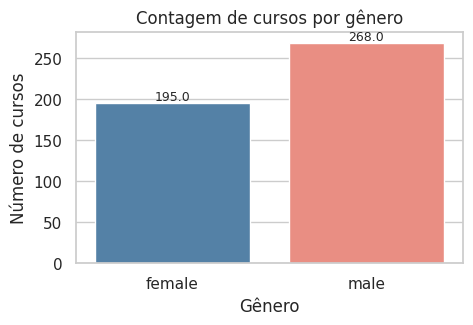

In [43]:
plt.figure(figsize=(5, 3))
i = sns.countplot(x="gender", hue="gender", data=ratings_df, palette=["steelblue", "salmon"])
plt.title("Contagem de cursos por gênero")
plt.xlabel("Gênero")
plt.ylabel("Número de cursos")
for p in i.patches:
    height = p.get_height()
    i.annotate(text=str(height), xy=(p.get_x() + p.get_width() / 2 , height), ha='center', va='bottom', fontsize=9)
plt.show()

🟣 **Interpretação**
- Homens ministraram mais cursos do que mulheres.
- Este é um gráfico de **comparação**.
- Countplot é ideal para frequências absolutas.

🟣 **Boas práticas**
- Ordene categorias quando fizer sentido.
- Use cores consistentes ao longo do notebook.
- Evite excesso de categorias (ideal ≤ 8).

## 🔵 4.2 Barplot — comparação de médias entre grupos

- Pergunta respondida:
    > **Como a média de uma variável numérica varia entre categorias?**

**Exemplo**: avaliação média (`eval`) por divisão (`division`).

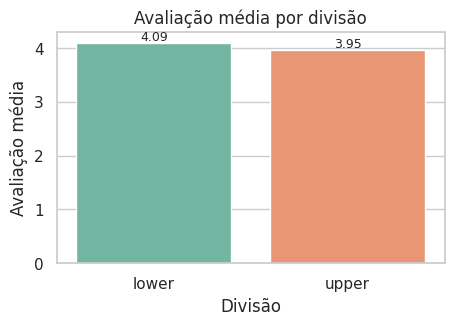

,division,count,mean,std,min,25%,50%,75%,max
0,lower,157.0,4.087261,0.591578,2.5,3.7,4.1,4.6,5.0
1,upper,306.0,3.952614,0.530273,2.1,3.6,4.0,4.4,5.0


In [68]:
plt.figure(figsize=(5, 3))
division_eval = ratings_df.groupby("division")["eval"].mean().reset_index()

i = sns.barplot(x="division", y="eval", hue="division", data=division_eval, palette="Set2")
plt.title("Avaliação média por divisão")
plt.xlabel("Divisão")
plt.ylabel("Avaliação média")
for p in i.patches:
    height = p.get_height()
    i.annotate(text=f"{height:.2f}", xy=(p.get_x() + p.get_width() / 2 , height), ha='center', va='bottom', fontsize=9)
plt.show()
ratings_df.groupby("division")["eval"].describe().reset_index()


🟣 **Interpretação**
- Cursos *lower division* têm avaliações ligeiramente maiores.
- Barplot é ideal para **comparar estatísticas resumidas** (médias, medianas).

🟣 **Boas práticas**
- Sempre mostrar rótulos claros.
- Evitar barras 3D.
- Preferir barras horizontais quando categorias forem longas.

## 🟣 4.3 Stacked Bar — composição dentro de categorias

- Pergunta respondida:
    > **Como uma categoria se divide em subcategorias?**

**Exemplo**: distribuição de **tenure** dentro de cada **gênero**.

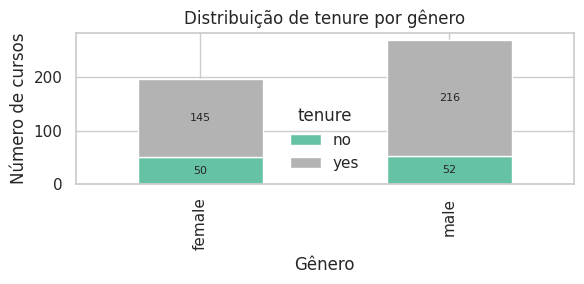

In [149]:
cross = ratings_df.groupby(["gender", "tenure"]).size().unstack()

i = cross.plot(kind="bar", stacked=True, figsize=(6, 3), colormap= "Set2")
plt.title("Distribuição de tenure por gênero")
plt.xlabel("Gênero")
plt.ylabel("Número de cursos")
for p in i.containers:
    i.bar_label(p, label_type="center", fontsize=8)
plt.tight_layout()
plt.show()

🟣 **Interpretação**
- Homens apresentam uma proporção maior de tenure (≈81%) em comparação às mulheres (≈74%).
- Entre as mulheres, a participação de cursos sem tenure é relativamente maior.
- Como o número total de cursos ministrados por homens é maior, isso também aumenta o volume absoluto de tenure no grupo masculino.

🟣 **Boas práticas**
- Use stacked bar apenas quando houver **poucas subcategorias**.
- Para muitas subcategorias → prefira facetamento (catplot).

## 🔵 4.4 Catplot — visualizações categóricas multivariadas

- O `catplot` é uma ferramenta poderosa para:
    - comparar categorias,
    - adicionar dimensões (hue, col, row),
    - criar painéis (facets),
    - explorar interações entre variáveis.

**Exemplo**: número de cursos por gênero e tenure.

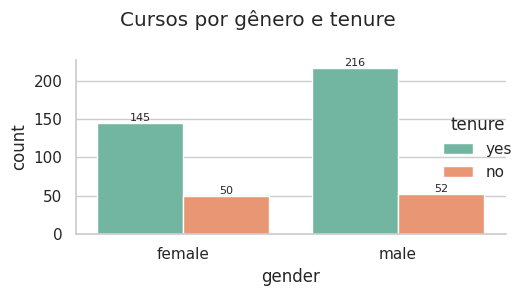

In [167]:
i = sns.catplot(x="gender", hue="tenure", kind="count", data=ratings_df,
                height=3, aspect=1.5, palette="Set2")
plt.suptitle("Cursos por gênero e tenure")

ax = i.ax
for p in ax.containers:
    ax.bar_label(p, fontsize=8)
plt.tight_layout()
plt.show()

🟣 **Interpretação**
- Visualização clara da interação entre gênero e tenure.
- `catplot` facilita análises multivariadas.

🟣 **Boas práticas**
- Use `row=` ou `col=` para criar painéis.
- Evite excesso de cores.
- Mantenha consistência visual.

## 🔵 4.5 Catplot com facetamento — múltiplas dimensões

- Pergunta:
    > **Como gênero e tenure variam dentro de cada divisão?**

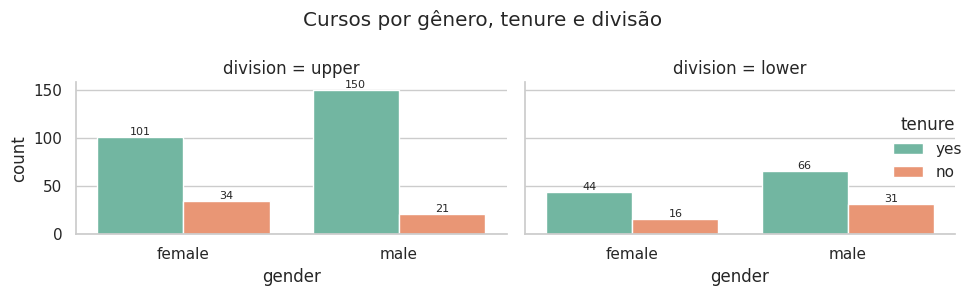

In [187]:
i = sns.catplot(x="gender", hue="tenure", col="division", kind="count", data=ratings_df,
            height=3, aspect=1.5, palette="Set2")
plt.suptitle("Cursos por gênero, tenure e divisão")
for ax in i.axes.flatten():
    for p in ax.containers:
        ax.bar_label(p, fontsize=8)
plt.tight_layout()
plt.show()

🟣 **Interpretação**
- Painéis permitem comparar padrões entre divisões.
- A leitura fica mais clara do que em gráficos empilhados.

🟣 **Quando usar facetamento**
- Quando há **duas ou mais variáveis categóricas**.
- Quando queremos comparar padrões entre grupos.

## 🟣 4.6 Pie Chart — quando usar (e quando evitar)

**O gráfico de pizza é um dos mais populares — e um dos mais mal utilizados.**

- ✔️ Quando usar:
    - poucas categorias (≤ 4),
    - proporções simples,
    - comunicação rápida.

- ❌ Quando evitar:
    - muitas categorias,
    - diferenças pequenas,
    - necessidade de precisão,
    - comparação entre múltiplos gráficos.

**Exemplo** (apenas para demonstração):

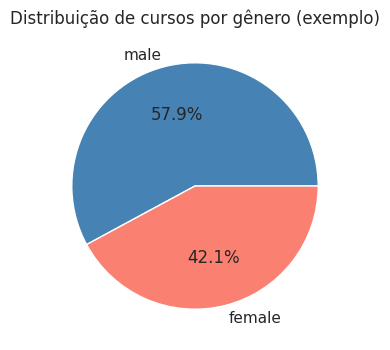

In [190]:
sizes = ratings_df["gender"].value_counts()
labels = sizes.index

plt.figure(figsize=(4, 4))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", colors=["steelblue", "salmon"])
plt.title("Distribuição de cursos por gênero (exemplo)")
plt.show()

🟣 **Interpretação**
- Diferenças pequenas são difíceis de perceber.
- Barras são quase sempre superiores.

> “The only worse design than a pie chart is several of them.”  
> — *Edward Tufte*

## 🟣 4.7 Storytelling visual com variáveis categóricas

Para transformar gráficos em **mensagens**, siga estes princípios:

1. ✔️ **Comece com uma pergunta**
    - Ex.: “Instrutores com tenure recebem mais avaliações?”

2. ✔️ **Escolha o gráfico certo**
    - Comparação → barras  
    - Composição → stacked bar  
    - Relação → facetamento  

3. ✔️ **Destaque o que importa**
    - cores,
    - anotações,
    - títulos informativos.

4. ✔️ **Remova ruído**
    - grades desnecessárias,
    - bordas pesadas,
    - legendas redundantes.

5. ✔️ **Conte a história**
    - “Instrutores homens ministram mais cursos e têm maior proporção de tenure.”
    - “Cursos lower division recebem avaliações ligeiramente maiores.”

<br>

> **Visualização é comunicação.**

<br>

### 🟠 Conteúdo avançado (opcional) — percepção de categorias

**A percepção de categorias depende de:**

1. **Similaridade**
    - Cores semelhantes → categorias relacionadas.

2. **Proximidade**
    - Barras próximas → comparação direta.

3. **Ordem**
    - Ordenar categorias melhora a leitura.

4. **Codificação redundante**
    - Cor + posição → leitura mais rápida.

5. **Escalas consistentes**
    - Comparações entre gráficos exigem escalas iguais.

<br>

>Esses princípios vêm da psicologia da Gestalt e da teoria da percepção visual.

<br>

---

<a id="numericas"></a>
[↑ - Índice](#indice)
# 5. Gráficos para variáveis numéricas


- **Variáveis numéricas representam quantidades**:
    - idade (`age`)
    - beleza (`beauty`)
    - avaliação (`eval`)
    - número de alunos (`students`)

- **Para esse tipo de variável, queremos entender**:
    - como os valores se distribuem,
    - se há assimetria,
    - se há outliers,
    - qual é a variabilidade,
    - como grupos se comparam.

- **Nesta seção, veremos**:
    - histograma  
    - KDE (densidade)  
    - boxplot  
    - violinplot  
    - ECDF (avançado)  
    - storytelling visual  
    - aplicações com teachingratings

## 🔵 5.1 Histograma — a ferramenta fundamental

O histograma é o gráfico mais importante para entender a distribuição de uma variável numérica.

- Pergunta respondida:
    > **Como os valores se distribuem ao longo do eixo numérico?**

<br>

**Exemplo**: distribuição de `age`.

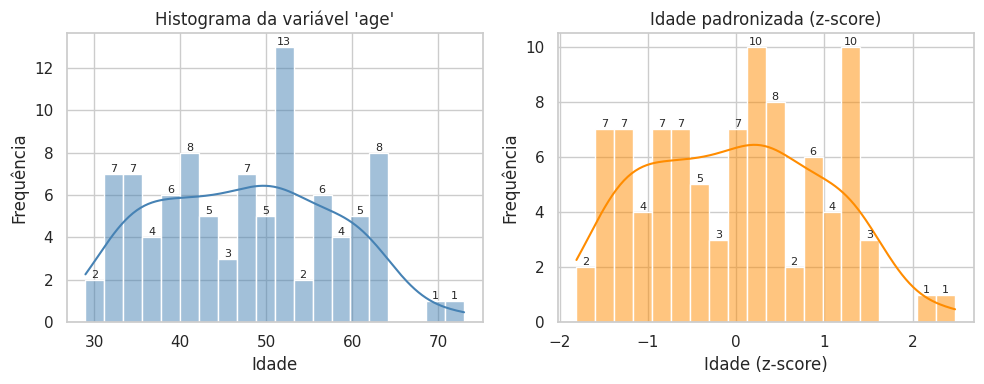

In [223]:
prof_df = ratings_df.groupby("prof")["age"].first()
age_z = (prof_df - prof_df.mean()) / prof_df.std()

fig, ax = plt.subplots(1, 2,figsize=(10, 4))
i = sns.histplot(ax=ax[0], data=prof_df, bins=20, kde=True, color="steelblue")
ax[0].set_title("Histograma da variável 'age'")
ax[0].set_xlabel("Idade")
ax[0].set_ylabel("Frequência")
for p in i.patches:
    height = p.get_height()
    if height > 0:
        i.annotate(str(int(height)), xy=(p.get_x() + p.get_width() / 2, height), ha="center", va="bottom", fontsize=8)

z = sns.histplot(ax=ax[1], data=age_z, bins=20, kde=True, color="darkorange")
ax[1].set_title("Idade padronizada (z-score)")
ax[1].set_xlabel("Idade (z-score)")
ax[1].set_ylabel("Frequência")
for p in z.patches:
    height = p.get_height()
    if height > 0:
        z.annotate(str(int(height)), xy=(p.get_x() + p.get_width() / 2, height), ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

🟣 **Interpretação**

- A idade dos instrutores varia amplamente, concentrando-se entre **30 e 70 anos**, mas com dispersão considerável.
- A distribuição é **assimétrica**, com uma cauda mais longa para idades mais altas.
- A padronização (z‑score) **não reduz a dispersão** — ela apenas desloca a média para 0 e ajusta a escala para unidades de desvio padrão.
- Como a variável já é naturalmente muito espalhada, o histograma padronizado também mostra **grande variação**.

🟣 **Boas práticas**

- Use entre **10 e 40 bins** para capturar a estrutura da distribuição.
- Evite bins muito largos (perdem detalhes importantes).
- Evite bins muito estreitos (introduzem ruído visual).
- Compare sempre o histograma original com o padronizado quando quiser mostrar **efeitos da padronização**.

🟣 **Nota importante sobre padronização**

- A padronização transforma a variável segundo: $ z = \frac{x - \bar{x}}{s} $

- Isso significa que:
    - a **média passa a ser 0**,  
    - o **desvio padrão passa a ser 1**,  
    - mas **a forma da distribuição permanece exatamente a mesma**.

- Ou seja:
    > **Padronizar não “normaliza” a variável — apenas muda o centro e a escala.**

<br>

Por isso, quando a variável original tem grande dispersão (como é o caso da idade dos instrutores), o histograma padronizado continua mostrando uma distribuição bastante espalhada. A padronização facilita comparações entre variáveis, mas não altera a variabilidade intrínseca dos dados.

<br>

## 🔵 5.2 KDE — Kernel Density Estimation

A KDE é uma versão **suavizada** do histograma.

- Pergunta respondida:
    > **Qual é a forma suave da distribuição?**

**Exemplo**: distribuição de `beauty`.

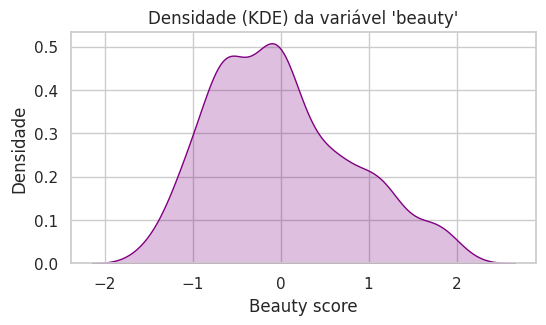

In [222]:
plt.figure(figsize=(6, 3))
sns.kdeplot(ratings_df["beauty"], fill=True, color="purple")
plt.title("Densidade (KDE) da variável 'beauty'")
plt.xlabel("Beauty score")
plt.ylabel("Densidade")
plt.show()

🟣 **Interpretação**
- A curva mostra a forma geral da distribuição.
- É útil para identificar:
  - assimetria,
  - multimodalidade,
  - caudas longas.

🟣 **Boas práticas**
- Sempre combine KDE com histograma quando possível.
- Evite KDE para amostras muito pequenas (n < 30).
- Quando utilizar somente KDE não é recomentado apresentar valores na curva

## 🟣 5.3 Histograma + KDE — visão completa

**Exemplo**: distribuição de `eval`.

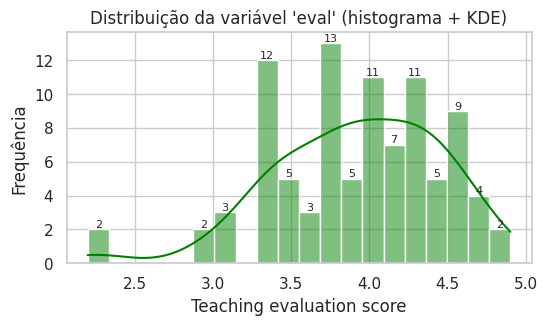

In [229]:
plt.figure(figsize=(6, 3))
prof_df = ratings_df.groupby("prof")["eval"].first()

i =sns.histplot(prof_df, bins=20, kde=True, color="green")
plt.title("Distribuição da variável 'eval' (histograma + KDE)")
plt.xlabel("Teaching evaluation score")
plt.ylabel("Frequência")
for p in i.patches:
    height = p.get_height()
    if height > 0:
        i.annotate(str(int(height)), xy=(p.get_x() + p.get_width() / 2, height), ha="center", va="bottom", fontsize=8)
plt.show()

🟣 **Interpretação**
- A distribuição é concentrada entre 3.5 e 4.5.
- Há poucos valores extremos.
- A forma lembra uma Normal, mas com leve assimetria.

🟣 **Quando usar histograma + KDE**
- Para explorar a forma da distribuição.
- Para comunicar padrões de forma clara.

## 🔵 5.4 Boxplot — mediana, quartis e outliers

O boxplot é ideal para comparar distribuições entre grupos.

- Pergunta respondida:
    > **Como a distribuição de uma variável numérica varia entre categorias?**

**Exemplo**: idade por gênero.

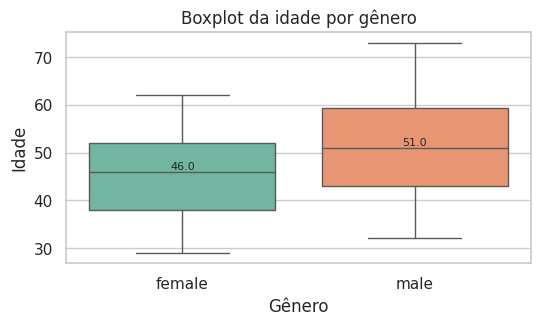

In [235]:
plt.figure(figsize=(6, 3))
i = sns.boxplot(x="gender", y="age", hue="gender", data=ratings_df, palette="Set2")
for p, gender in enumerate(ratings_df["gender"].unique()):
    mediana = ratings_df.loc[ratings_df["gender"] == gender, "age"].median()
    i.text(p, mediana, f"{mediana:.1f}", ha="center", va="bottom", fontsize=8)
plt.title("Boxplot da idade por gênero")
plt.xlabel("Gênero")
plt.ylabel("Idade")
plt.show()

🟣 **Interpretação**
- Homens tendem a ser mais velhos que mulheres.
- A mediana masculina é maior.
- A dispersão é semelhante entre os grupos.

🟣 **Boas práticas**
- Use boxplot para comparar grupos.
- Combine com violinplot quando quiser ver densidade.

## 🔵 5.5 Violinplot — distribuição + boxplot

- O violinplot combina:
    - KDE (densidade),
    - boxplot,
    - simetria visual.

- Pergunta respondida:
    > **Como a distribuição completa se compara entre grupos?**

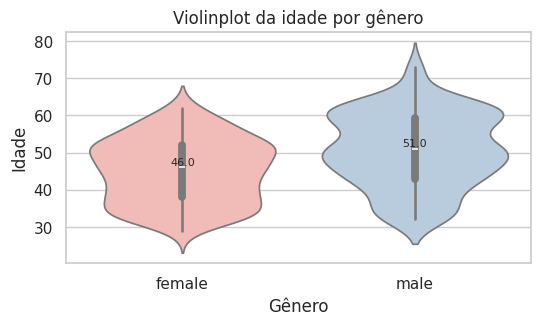

In [238]:
plt.figure(figsize=(6, 3))
i = sns.violinplot(x="gender", y="age", hue="gender", data=ratings_df, palette="Pastel1")
for p, gender in enumerate(ratings_df["gender"].unique()):
    mediana = ratings_df.loc[ratings_df["gender"] == gender, "age"].median()
    i.text(p, mediana, f"{mediana:.1f}", ha="center", va="bottom", fontsize=8)
plt.title("Violinplot da idade por gênero")
plt.xlabel("Gênero")
plt.ylabel("Idade")
plt.show()

🟣 **Interpretação**
- Mostra a densidade completa da distribuição.
- Permite ver:
  - caudas,
  - assimetria,
  - multimodalidade.

🟣 **Quando usar**
- Quando a forma da distribuição importa.
- Quando há muitos dados.

## 🟣 5.6 Comparando grupos com boxplot + swarmplot

O swarmplot mostra cada ponto individual.

**Exemplo**: beleza por gênero.

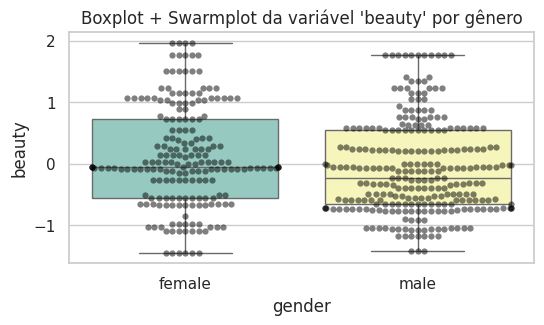

In [246]:
plt.figure(figsize=(6, 3))
sns.boxplot(x="gender", y="beauty", hue="gender", data=ratings_df, palette="Set3")
sns.swarmplot(x="gender", y="beauty", data=ratings_df, color="black", alpha=0.5, size=4.5)
plt.title("Boxplot + Swarmplot da variável 'beauty' por gênero")
plt.show()

🟣 **Interpretação**
- A nuvem de pontos mostra a variabilidade real.
- O boxplot resume a distribuição.

🟣 **Boas práticas**
- Use swarmplot apenas para amostras pequenas/médias.
- Para amostras grandes → prefira violinplot.

## 🟣 5.7 ECDF — Empirical Cumulative Distribution Function (avançado)

- A ECDF mostra:
    - a proporção de valores abaixo de cada ponto,
    - a forma acumulada da distribuição.

- Pergunta respondida:
    > **Qual a probabilidade de a variável assumir valores menores que x?**

**Exemplo**: ECDF de `eval`.

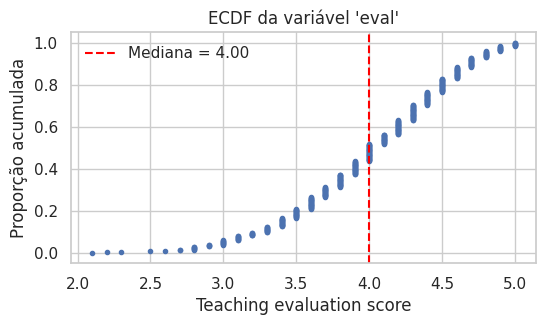

In [250]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x, y = ecdf(ratings_df["eval"])

plt.figure(figsize=(6, 3))
plt.plot(x, y, marker=".", linestyle="none")
plt.title("ECDF da variável 'eval'")
plt.xlabel("Teaching evaluation score")
plt.ylabel("Proporção acumulada")

median = ratings_df["eval"].median()
plt.axvline(median, color="red", linestyle="--", label=f"Mediana = {median:.2f}")
plt.legend()

plt.show()

🟣 **Interpretação**
- A ECDF permite comparar distribuições sem perder informação.
- É mais informativa que histogramas.

🟠 **Quando usar ECDF**
- Em análises estatísticas avançadas.
- Para comparar distribuições com precisão.
- Para detectar diferenças sutis entre grupos.

### 🟠 Conteúdo avançado (opcional) — matemática da ECDF e KDE

**ECDF**

- A ECDF é definida como:  

    | $$ F_n(x) = \frac{1}{n} \sum_{i=1}^n \mathbf{1}(X_i \le x) $$ |
    |-|

Ela converge para a CDF verdadeira pela **Lei dos Grandes Números**.

<br>

**KDE**

- A KDE é definida como:  

    | $$ \hat{f}(x) = \frac{1}{nh} \sum_{i=1}^n K\left(\frac{x - X_i}{h}\right) $$ |
    |-|

<br>

- onde:
    - $K$ é o kernel (normal, Epanechnikov, etc.),
    - $h$ é o bandwidth (suavização).

- O bandwidth controla:
    - **h pequeno** → curva ruidosa  
    - **h grande** → curva super-suavizada  

A escolha ótima de $h$ é um problema clássico em estatística.

<br>

## 🟣 5.8 Storytelling visual com variáveis numéricas

- **Para transformar gráficos em narrativa:**

    1. ✔️ **Destaque tendências**
        - “A maioria das avaliações está entre 3.5 e 4.5.”

    2. ✔️ **Mostre outliers**
        - “Há poucos instrutores com avaliação abaixo de 2.”

    3. ✔️ **Compare grupos**
        - “Instrutores homens são mais velhos em média.”

    4. ✔️ **Use títulos informativos**
        - “Distribuição da idade dos instrutores” é melhor que “Histograma”.

    5. ✔️ **Combine gráficos**
        - Histograma + KDE  
        - Boxplot + Swarmplot  
        - ECDF + Boxplot  

<br>

> Visualização é comunicação.

<br>

---


<a id="variaveis"></a>
[↑ - Índice](#indice)
# 6. Relações entre variáveis


Até agora, analisamos variáveis isoladas.
Agora vamos explorar **como elas se relacionam entre si**.

- Relações entre variáveis são fundamentais para:
    - identificar padrões,
    - detectar correlações,
    - entender comportamentos,
    - construir modelos estatísticos e de machine learning.

- Nesta seção, veremos:
    - scatterplot  
    - bubble chart  
    - regplot (reta de regressão)  
    - lmplot (regressão multivariada)  
    - pairplot (matriz de relações)  
    - FacetGrid (painéis condicionais)  
    - storytelling visual  
    - aplicações com teachingratings

## 🔵 6.1 Scatterplot — o gráfico mais importante para relações numéricas

- Pergunta respondida:
    > **Como duas variáveis numéricas se relacionam?**

Exemplo: idade × avaliação (`age` × `eval`).

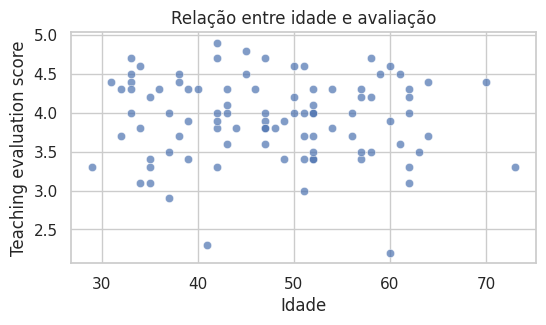

In [23]:
teach_df = ratings_df.groupby("prof")[["age", "eval"]].first()

plt.figure(figsize=(6, 3))
sns.scatterplot(x="age", y="eval", data=teach_df, alpha=0.7)
plt.title("Relação entre idade e avaliação")
plt.xlabel("Idade")
plt.ylabel("Teaching evaluation score")
plt.show()

🟣 **Interpretação**
- Não há relação linear forte entre idade e avaliação.
- A nuvem de pontos é dispersa.
- Scatterplots são essenciais para detectar:
  - correlação,
  - padrões,
  - clusters,
  - outliers.

## 🔵 6.2 Scatterplot com cor (hue) — adicionando uma dimensão categórica

- Pergunta:
    > **A relação muda entre homens e mulheres?**

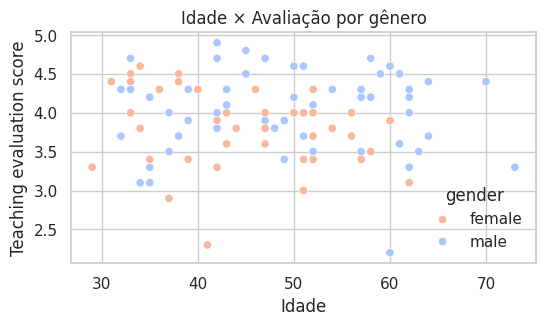

In [131]:
teach_df = ratings_df.groupby("prof")[["age", "eval", "gender"]].first()

plt.figure(figsize=(6, 3))
sns.scatterplot(x="age", y="eval", hue="gender", data=teach_df, palette="coolwarm_r")
plt.title("Idade × Avaliação por gênero")
plt.xlabel("Idade")
plt.ylabel("Teaching evaluation score")

plt.show()

🟣 **Interpretação**
- A cor permite comparar grupos.
- Não há diferença clara entre gêneros na relação idade × avaliação.

🟣 **Boas práticas**
- Use `hue` para destacar categorias.
- Mantenha cores consistentes ao longo do notebook.

## 🔵 6.3 Bubble Chart — adicionando uma terceira variável numérica

- Pergunta:
    > **Como idade, avaliação e número de alunos se relacionam?**

- Usaremos:
    - x = idade  
    - y = avaliação  
    - tamanho = número de alunos (`students`)

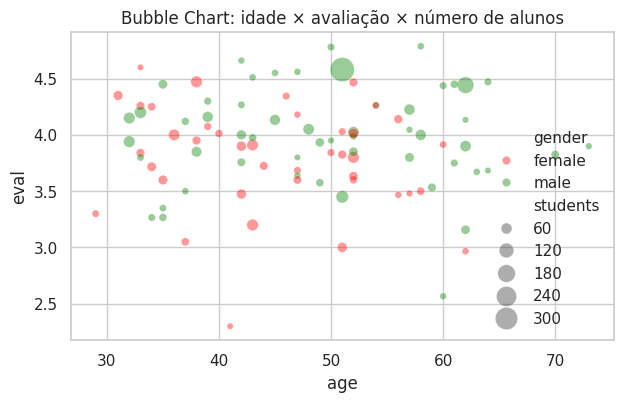

,gender,nProfessores,mediaTotalAlunos,mediaAvaliação
0,female,40,1293.018101,3.793253
1,male,54,2129.588220,3.989405
2,Total,94,3422.606321,3.891329


In [133]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "age": "first", "students": "mean", "eval": "mean"}).reset_index()

plt.figure(figsize=(7, 4))
sns.scatterplot(x="age", y="eval", size="students", sizes=(20, 300),
    hue="gender", data=teach_df, alpha=0.4, palette={"female": "red", "male": "green"})
plt.title("Bubble Chart: idade × avaliação × número de alunos")
plt.show()

qtde = teach_df.groupby("gender").agg(nProfessores=("prof", "count"), mediaTotalAlunos=("students", "sum"), mediaAvaliação=("eval", "mean")).reset_index()
total = pd.DataFrame({"gender": ["Total"], "nProfessores": [qtde["nProfessores"].sum()], "mediaTotalAlunos": [qtde["mediaTotalAlunos"].sum()], "mediaAvaliação": [qtde["mediaAvaliação"].mean()]})
Resultado = pd.concat([qtde, total], ignore_index=True)
display(Resultado)

🟣 **Interpretação**
- Bolhas maiores representam **instrutores com mais alunos avaliando**.
- Observa-se uma **concentração de alunos** em torno de avaliações entre aproximadamente 3,5 e 4,5.
- O gráfico evidencia como o **volume de alunos** se distribui ao longo das avaliações, permitindo ver onde há maior concentração de observações.

🟣 **Quando usar bubble charts**
- Para visualizar **três variáveis simultaneamente**: duas posições (x e y) e uma magnitude (tamanho).
- Para destacar **concentração ou volume** de observações.
- Para explorar padrões que dependem do **tamanho da amostra por ponto**, como número de alunos por instrutor.


## 🔵 6.4 Regplot — adicionando linha de tendência

- Pergunta:
    > **Existe tendência linear entre idade e avaliação?**

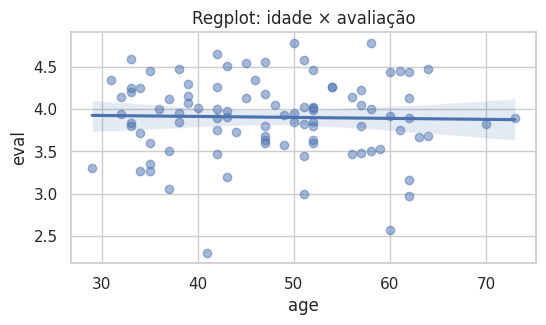

In [81]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "age": "first", "students": "mean", "eval": "mean"}).reset_index()

plt.figure(figsize=(6, 3))
sns.regplot(x="age", y="eval", data=teach_df, scatter_kws={"alpha": 0.5})
plt.title("Regplot: idade × avaliação")
plt.show()

🟣 **Interpretação**
- A linha de regressão é quase horizontal.
- Indica **correlação fraca**.

🟣 **Boas práticas**
- Use regplot para explorar relações lineares.
- Combine com scatterplot para ver dispersão.

## 🔵 6.5 Lmplot — regressão condicionada por categorias

- Pergunta:
    > **A relação idade × avaliação muda entre gêneros?**

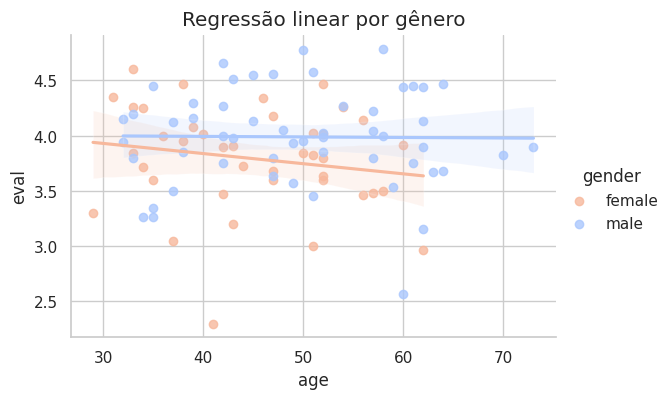

In [135]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "age": "first", "students": "mean", "eval": "mean"}).reset_index()

sns.lmplot(x="age", y="eval", hue="gender", data=teach_df, height=3.9, aspect=1.5, palette="coolwarm_r")
plt.suptitle("Regressão linear por gênero", y=1.02)
plt.show()

🟣 **Interpretação**
- As linhas de regressão são quase paralelas.
- Não há diferença significativa entre gêneros.

🟣 **Quando usar lmplot**
- Para regressões condicionadas por categorias.
- Para explorar interações.

## 🔵 6.6 Pairplot — matriz de relações

- Pergunta:
    > **Como várias variáveis se relacionam entre si?**

**Exemplo**: idade, beleza e avaliação.

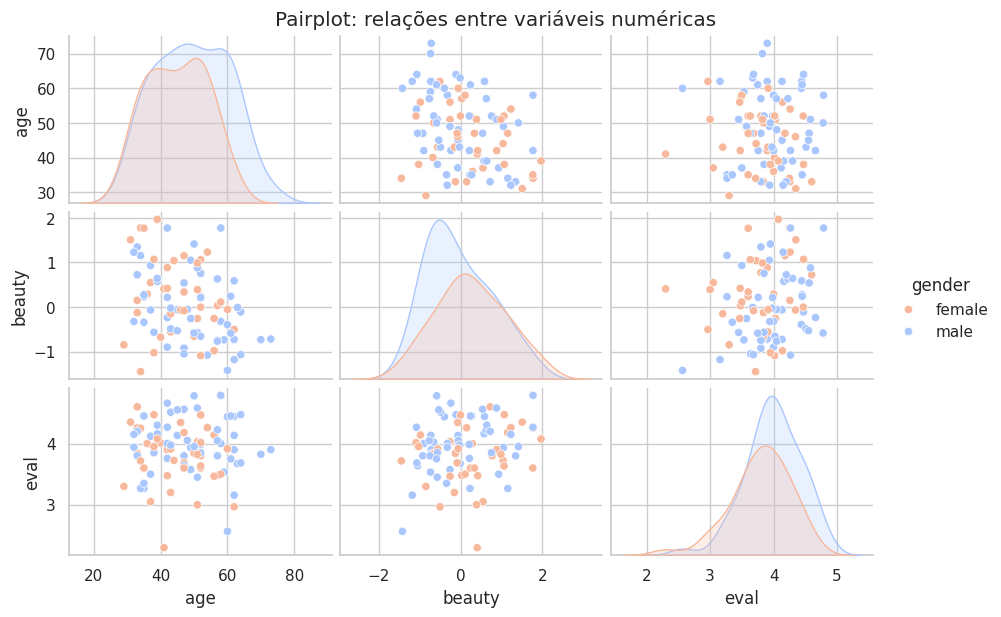

In [150]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "beauty": "first", "age": "first", "eval": "mean"}).reset_index()

sns.pairplot(teach_df[["age", "beauty", "eval", "gender"]], hue="gender", height=2, aspect=1.5, diag_kind="kde", palette="coolwarm_r")
plt.suptitle("Pairplot: relações entre variáveis numéricas", y=1.02)
plt.show()

🟣 **Interpretação**
- Pairplot revela padrões globais.
- Permite detectar correlações e clusters.

🟣 **Boas práticas**
- Use pairplot apenas com poucas variáveis (≤ 6).
- Para datasets grandes, use amostragem.

## 🔵 6.7 FacetGrid — múltiplos gráficos condicionados

- Pergunta:
    > **Como idade × avaliação varia por gênero e tenure?**

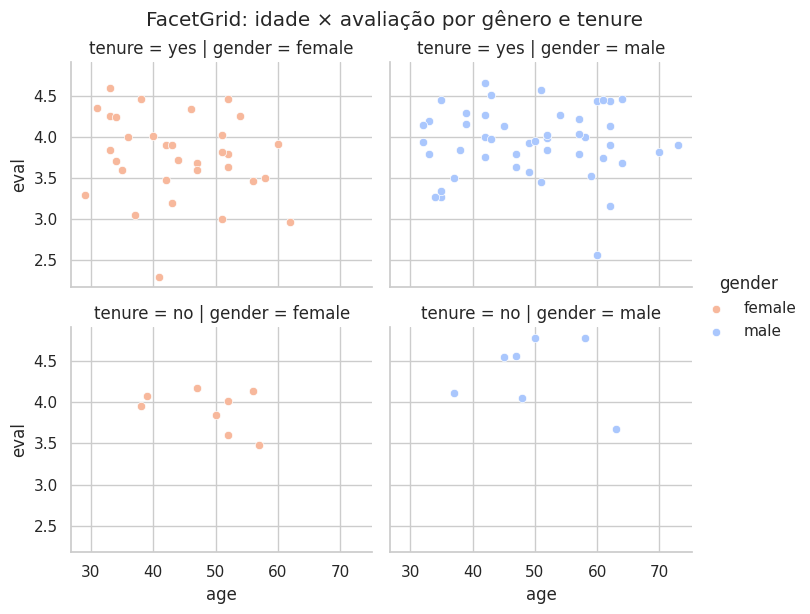

In [154]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "age": "first", "tenure": "first", "eval": "mean"}).reset_index()
g = sns.FacetGrid(teach_df, row="tenure", col="gender", height=3, aspect=1.2, hue="gender", palette="coolwarm_r")
g.map_dataframe(sns.scatterplot, x="age", y="eval") #, alpha=0.6)
g.add_legend()
plt.suptitle("FacetGrid: idade × avaliação por gênero e tenure", y=1.02)
plt.show()

🟣 **Interpretação**
- Painéis permitem comparar padrões entre grupos.
- Diferenças sutis ficam mais claras.

🟣 **Quando usar FacetGrid**
- Quando há **duas ou mais variáveis categóricas**.
- Para explorar interações complexas.

### 🟠 Conteúdo avançado (opcional) — correlação e regressão

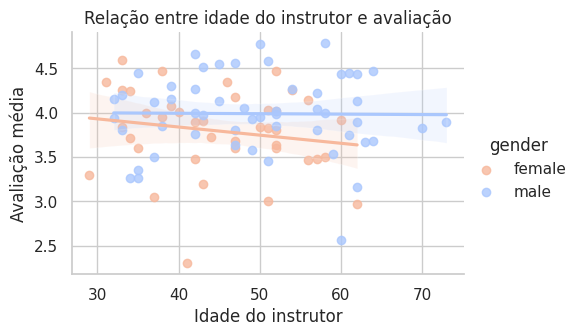

In [167]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "age": "first", "eval": "mean"}).reset_index()

sns.lmplot(x="age", y="eval", hue="gender", data=teach_df, height=3.3, aspect=1.5, palette="coolwarm_r")
plt.title("Relação entre idade do instrutor e avaliação")
plt.xlabel("Idade do instrutor")
plt.ylabel("Avaliação média")
plt.show()


- O gráfico acima mostra a relação entre:
    - **idade do instrutor** (eixo x),
    - **avaliação média recebida** (eixo y),
    - **gênero** (cores),
    - **tendência linear por grupo** (linhas de regressão com intervalo de confiança).

Esse tipo de visualização é ideal para introduzir correlação e regressão, pois permite observar padrões antes de aplicar qualquer modelo estatístico.

<br>


- **Correlação de Pearson**
    - Mede a força de uma **relação linear** entre duas variáveis:  

        | $$ r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}} $$ |
        |-|

        **Como o gráfico ajuda a interpretar:**

        - As linhas de regressão mostram uma **tendência levemente negativa**: instrutores mais velhos tendem a receber avaliações um pouco menores.
        - A dispersão dos pontos indica que a correlação é **fraca**.
        - A inclinação das linhas (uma para cada gênero) sugere que o padrão é semelhante entre grupos.

<br>

- **Correlação de Spearman**
    - Mede relações **monotônicas**, mesmo quando não são lineares.
    - Baseia-se na ordem (ranks), não nos valores brutos.

        **No gráfico:**

        - Como a tendência é suave e consistente, Spearman também capturaria essa relação negativa, mesmo que ela não fosse perfeitamente linear.

<br>

- **Regressão linear simples**
    - Modelo para explicar ou prever uma variável a partir de outra:  

        | $$ y = \beta_0 + \beta_1 x + \varepsilon $$ |
        |-|

        **Como o gráfico ajuda a interpretar:**

        - As linhas de regressão representam a **reta ajustada** para cada gênero.
        - A inclinação $ (( \beta_1 )) $ é negativa, indicando que avaliações tendem a diminuir com a idade.
        - A largura da faixa sombreada mostra a **incerteza** da estimativa.
        - A dispersão dos pontos ao redor da linha indica que a relação é **fraca**, apesar de existir.

<br>

- **Por que visualizar antes de modelar?**
    - A visualização revela rapidamente se existe algum padrão.
    - Evita aplicar correlação ou regressão quando **não há relação alguma**.
    - Ajuda a identificar diferenças entre grupos (como gênero).
    - Permite avaliar se a relação parece linear (Pearson) ou apenas monotônica (Spearman).
    - Mostra se outliers podem influenciar a inclinação da linha.

    > O scatterplot com linhas de regressão por grupo é uma das formas mais poderosas de conectar análise exploratória com modelagem estatística.


## 🟣 6.8 Storytelling visual com relações entre variáveis

- **Para transformar relações em narrativa:**

    1. ✔️ **Destaque tendências**
        - “A relação entre idade e avaliação é fraca.”

    2. ✔️ **Compare grupos**
        - “Homens e mulheres têm padrões semelhantes.”

    3. ✔️ **Use painéis para interações**
        - “Instrutores com tenure têm padrões mais estáveis.”

    4. ✔️ **Combine gráficos**
        - scatterplot + regplot  
        - lmplot + FacetGrid  

    5. ✔️ **Use títulos informativos**
        - “Idade × Avaliação por gênero e tenure”

<br>

> Visualização é comunicação.

<br>

---

<a id="storytelling"></a>
[↑ - Índice](#indice)
# 7. Storytelling com Dados

> Visualização não é apenas análise — é **comunicação**.

- Um gráfico pode:
    - revelar um padrão,
    - convencer uma audiência,
    - explicar um fenômeno,
    - ou até mudar uma decisão.

Nesta seção, vamos aprender como transformar gráficos em **histórias visuais**.

- Veremos:
    - princípios de narrativa visual,
    - como destacar o que importa,
    - como reduzir ruído,
    - como guiar o olhar do leitor,
    - como comunicar achados com clareza,
    - exemplos aplicados ao dataset *teachingratings*.

## 🔵 7.1 O que é storytelling com dados?

- Storytelling com dados é a arte de:
    > **usar gráficos para comunicar uma mensagem clara, objetiva e memorável.**

- Não basta mostrar um gráfico — é preciso:
    - contextualizar,
    - interpretar,
    - destacar,
    - explicar,
    - guiar.

- Um bom gráfico responde:
    - **o quê** (o dado mostra),
    - **por quê** (isso importa),
    - **e agora?** (qual é a implicação).

## 🟣 7.2 Os 3 pilares do storytelling visual

- **1. Mensagem**
    - Qual pergunta estamos respondendo?
    - Qual insight queremos comunicar?

- **2. Evidência**
    - Qual gráfico melhor representa essa mensagem?
    - Quais dados sustentam o argumento?

- **3. Design**
    - Como destacar o que importa?
    - Como reduzir ruído?
    - Como guiar o olhar?

## 🟣 7.3 Estrutura clássica de uma história com dados

**Inspirada em Cole Nussbaumer Knaflic (*Storytelling with Data*):**

```text
    ➡️    Contexto    ➡️  Exploração  ➡️      Insight     ➡️      Ação
```

<br>

1. **Contexto**
    - Qual é a pergunta?
    - Qual é o problema?

2. **Exploração**
    - O que os dados mostram?
    - Quais padrões surgem?

3. **Insight**
    - Qual é a descoberta principal?

4. **Ação**
    - O que deve ser feito?
    - Qual é a implicação prática?

## 🔵 7.4 Exemplo aplicado — Avaliação média por divisão

- Pergunta:
    > **Cursos lower division recebem avaliações mais altas?**

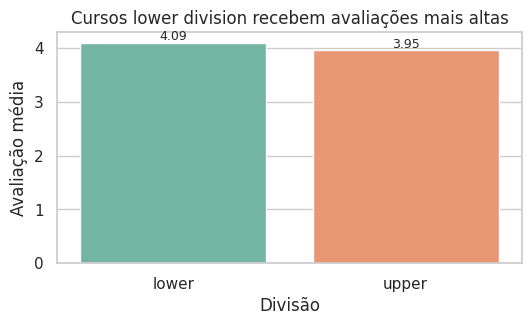

In [7]:
division_eval = ratings_df.groupby("division")["eval"].mean().reset_index()

plt.figure(figsize=(6, 3))
i = sns.barplot(x="division", y="eval", hue="division", data=division_eval, palette="Set2")
plt.title("Cursos lower division recebem avaliações mais altas")
plt.xlabel("Divisão")
plt.ylabel("Avaliação média")
for p in i.patches:
    height = p.get_height()
    i.annotate(text=f"{height:.2f}", xy=(p.get_x() + p.get_width() / 2 , height), ha='center', va='bottom', fontsize=9)
plt.show()

🟣 **Storytelling**

- Cursos *lower division* têm avaliação média maior.
- Diferença é pequena, mas consistente.
- Pode indicar:
  - turmas menores,
  - conteúdos introdutórios,
  - expectativas diferentes.

O título já comunica a mensagem principal.

## 🔵 7.5 Exemplo aplicado — Idade × Avaliação por gênero

- Pergunta:
    > **A relação entre idade e avaliação muda entre homens e mulheres?**

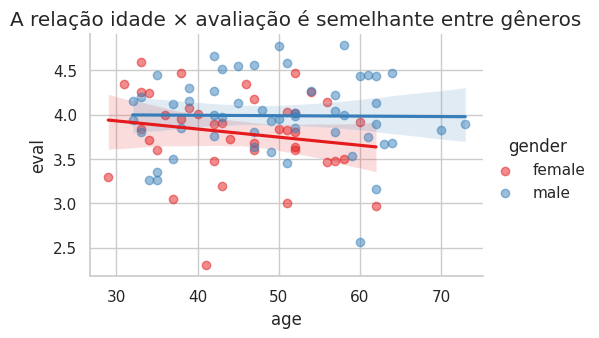

In [16]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "age": "first", "eval": "mean"}).reset_index()

sns.lmplot(x="age", y="eval", hue="gender", data=teach_df, height=3.3, aspect=1.5, palette="Set1", scatter_kws={"alpha": 0.5})
plt.suptitle("A relação idade × avaliação é semelhante entre gêneros", y=1.02)
plt.show()

🟣 **Storytelling**

- As linhas de regressão são quase paralelas.
- Não há diferença significativa entre gêneros.
- A dispersão é semelhante.

O título já entrega o insight.

## 🟣 7.6 Como destacar o que importa

1. ✔️ **Use títulos informativos**
    - “Distribuição de idade” → fraco  
    - “**Instrutores homens são mais velhos em média**” → forte

2. ✔️ **Use cores com propósito**
    - Cores diferentes → categorias diferentes  
    - Cores iguais → mesma categoria  

3. ✔️ **Use anotações**
    - Destaque pontos importantes.

4. ✔️ **Remova ruído**
    - Linhas de grade desnecessárias,
    - bordas pesadas,
    - legendas redundantes.

5. ✔️ **Use hierarquia visual**
    - Título → maior  
    - Subtítulo → médio  
    - Texto → menor  

## 🔵 7.7 Exemplo aplicado — destacando outliers

- Pergunta:
    > **Existem instrutores com avaliação muito baixa?**

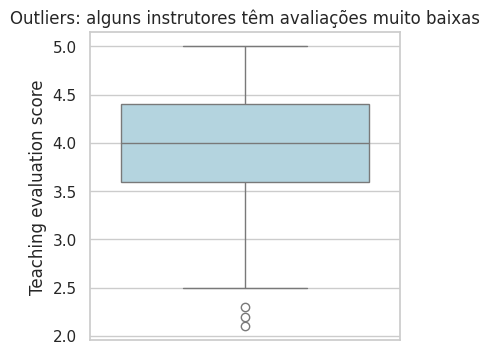

In [19]:
plt.figure(figsize=(4, 4))
sns.boxplot(y="eval", data=ratings_df, color="lightblue")
plt.title("Outliers: alguns instrutores têm avaliações muito baixas")
plt.ylabel("Teaching evaluation score")
plt.show()

🟣 **Storytelling**

- A maioria das avaliações está entre 3.5 e 4.5.
- Há alguns outliers abaixo de 2.5.
- Esses casos podem merecer investigação.

## 🟣 7.8 Como guiar o olhar do leitor

1. ✔️ **Coloque o insight no título**
    - O leitor entende a mensagem antes de ver o gráfico.

2. ✔️ **Destaque com cor**
    - Uma cor forte chama atenção imediatamente.

3. ✔️ **Use anotações**
    - Pequenos textos ajudam a explicar pontos importantes.

4. ✔️ **Use layout limpo**
    - Menos elementos → mais clareza.

## 🔵 7.9 Exemplo aplicado — destacando diferença entre grupos

- Pergunta:
    > **Instrutores com tenure têm avaliações diferentes?**

/tmp/ipykernel_2451/1406450991.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  i = sns.barplot(x="tenure", y="eval", data=tenure_eval, palette="Set2")


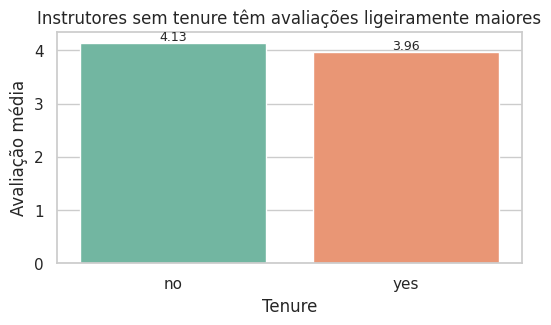

In [27]:
tenure_eval = ratings_df.groupby("tenure")["eval"].mean().reset_index()

plt.figure(figsize=(6, 3))
i = sns.barplot(x="tenure", y="eval", data=tenure_eval, palette="Set2")
plt.title("Instrutores sem tenure têm avaliações ligeiramente maiores")
plt.xlabel("Tenure")
plt.ylabel("Avaliação média")
for p in i.patches:
    height = p.get_height()
    i.annotate(text=f"{height:.2f}", xy=(p.get_x() + p.get_width() / 2 , height), ha='center', va='bottom', fontsize=9)
plt.show()

🟣 **Storytelling**

- A diferença é pequena, mas existe.
- Pode refletir:
  - carga de trabalho,
  - tipo de curso,
  - experiência,
  - expectativas dos alunos.

### 🟠 Conteúdo avançado (opcional) — narrativa visual profissional

- **Técnicas usadas em consultorias e jornalismo de dados**:

1. **Pirâmide invertida**
    - Comece pelo insight principal → depois detalhes.

2. **Redução de entropia**
    - Remova tudo que não contribui para a mensagem.

3. **Codificação redundante**
    - Cor + posição + texto → leitura mais rápida.

4. **Anotações inteligentes**
    - Destaque apenas o essencial.

5. **Hierarquia visual**
    - Título > subtítulo > gráfico > legenda.

6. **Story-first, chart-second**
    - Primeiro a história, depois o gráfico.

<br>

---

<a id="teaching-ratings"></a>
[↑ - Índice](#indice)
# 8. Aplicações com teachingratings

- Agora vamos aplicar tudo o que aprendemos sobre:
    - gráficos categóricos,
    - gráficos numéricos,
    - relações entre variáveis,
    - storytelling visual,
    - boas práticas de design.

- O dataset *teachingratings* é ideal para isso porque contém:
    - variáveis categóricas (gender, tenure, division),
    - variáveis numéricas (age, beauty, eval),
    - relações multivariadas interessantes.

Vamos explorar padrões reais e extrair insights.

## 🔵 8.1 Estrutura do dataset

Antes de analisar, revisamos a estrutura.

In [28]:
ratings_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 463 entries, 0 to 462
Data columns (total 19 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   minority         463 non-null    str    
 1   age              463 non-null    int64  
 2   gender           463 non-null    str    
 3   credits          463 non-null    str    
 4   beauty           463 non-null    float64
 5   eval             463 non-null    float64
 6   division         463 non-null    str    
 7   native           463 non-null    str    
 8   tenure           463 non-null    str    
 9   students         463 non-null    int64  
 10  allstudents      463 non-null    int64  
 11  prof             463 non-null    int64  
 12  PrimaryLast      463 non-null    int64  
 13  vismin           463 non-null    int64  
 14  female           463 non-null    int64  
 15  single_credit    463 non-null    int64  
 16  upper_division   463 non-null    int64  
 17  English_speaker  463 non-nu

🟣 **Interpretação**
- 463 cursos avaliados.
- 94 instrutores únicos.
- Variáveis categóricas e numéricas bem definidas.

Isso permite análises ricas e multivariadas.

## 🔵 8.2 Estatísticas descritivas gerais

In [29]:
ratings_df.describe()

,age,beauty,eval,students,allstudents,prof,PrimaryLast,vismin,female,single_credit,upper_division,English_speaker,tenured_prof
count,463.000000,4.630000e+02,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000,463.000000
mean,48.365011,6.271140e-08,3.998272,36.624190,55.177106,45.434125,0.203024,0.138229,0.421166,0.058315,0.660907,0.939525,0.779698
std,9.802742,7.886477e-01,0.554866,45.018481,75.072800,27.508902,0.402685,0.345513,0.494280,0.234592,0.473913,0.238623,0.414899
min,29.000000,-1.450494e+00,2.100000,5.000000,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,-6.562689e-01,3.600000,15.000000,19.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,48.000000,-6.801430e-02,4.000000,23.000000,29.000000,44.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
75%,57.000000,5.456024e-01,4.400000,40.000000,60.000000,70.500000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000
max,73.000000,1.970023e+00,5.000000,380.000000,581.000000,94.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


🟣 **Insights iniciais**
- Avaliação média ≈ 4.0  
- Idade média ≈ 48 anos  
- Beauty score padronizado (média 0, desvio padrão 1)  
- Número de alunos varia bastante (turmas pequenas e grandes)

Esses números guiam nossas análises visuais.

# 🔵 8.3 Análise 1 — Avaliação média por gênero

- Pergunta:
    > **Instrutores homens e mulheres recebem avaliações diferentes?**

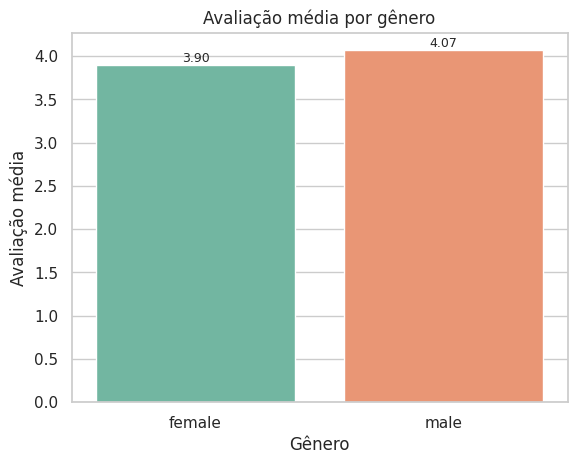

In [32]:
gender_eval = ratings_df.groupby("gender")["eval"].mean().reset_index()

i = sns.barplot(x="gender", y="eval", hue="gender", data=gender_eval, palette="Set2")
plt.title("Avaliação média por gênero")
plt.xlabel("Gênero")
plt.ylabel("Avaliação média")
for p in i.patches:
    height = p.get_height()
    i.annotate(text=f"{height:.2f}", xy=(p.get_x() + p.get_width() / 2 , height), ha='center', va='bottom', fontsize=9)
plt.show()

🟣 **Interpretação**
- Diferença pequena entre homens e mulheres.
- Não há evidência visual de viés forte.

🟣 **Storytelling**
- “Avaliações são semelhantes entre gêneros.”
- “Diferenças pequenas podem ser explicadas por variabilidade natural.”

# 🔵 8.4 Análise 2 — Avaliação média por tenure

- Pergunta:
    > **Instrutores com tenure recebem avaliações mais altas?**

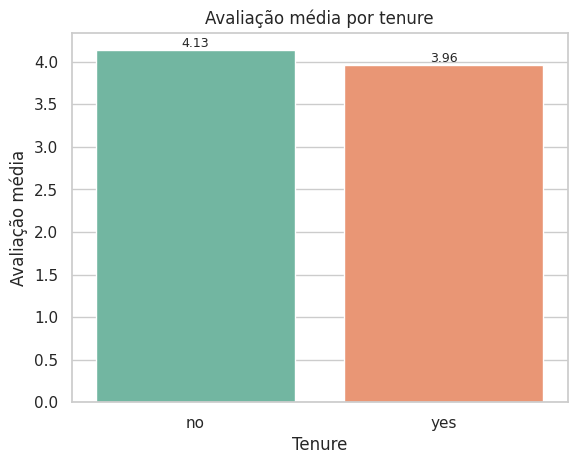

In [34]:
tenure_eval = ratings_df.groupby("tenure")["eval"].mean().reset_index()

i = sns.barplot(x="tenure", y="eval", hue="tenure", data=tenure_eval, palette="Set2")
plt.title("Avaliação média por tenure")
plt.xlabel("Tenure")
plt.ylabel("Avaliação média")
for p in i.patches:
    height = p.get_height()
    i.annotate(text=f"{height:.2f}", xy=(p.get_x() + p.get_width() / 2 , height), ha='center', va='bottom', fontsize=9)
plt.show()

🟣 **Interpretação**
- Instrutores sem tenure têm avaliações ligeiramente maiores.
- Diferença pequena, mas consistente.

🟣 **Possíveis explicações**
- Cursos introdutórios (lower division) podem ser ministrados por não-tenured.
- Expectativas dos alunos podem variar.

# 🔵 8.5 Análise 3 — Distribuição de idade por gênero

- Pergunta:
    > **Instrutores homens são mais velhos que mulheres?**

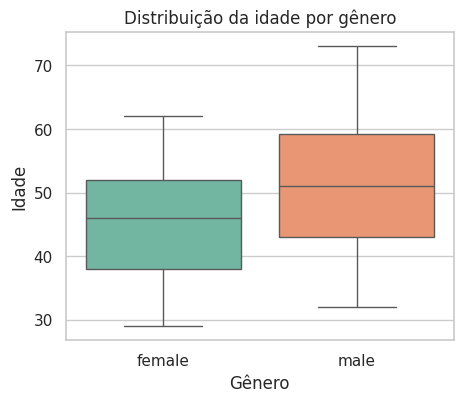

In [37]:
plt.figure(figsize=(5, 4))
sns.boxplot(x="gender", y="age", hue="gender", data=ratings_df, palette="Set2")
plt.title("Distribuição da idade por gênero")
plt.xlabel("Gênero")
plt.ylabel("Idade")
plt.show()

🟣 **Interpretação**
- Homens tendem a ser mais velhos.
- Mulheres têm distribuição mais concentrada.

🟣 **Storytelling**
- “A idade média dos instrutores homens é maior.”
- “Isso pode influenciar padrões de avaliação.”

# 🔵 8.6 Análise 4 — Relação idade × avaliação

- Pergunta:
    > **Instrutores mais velhos recebem avaliações diferentes?**

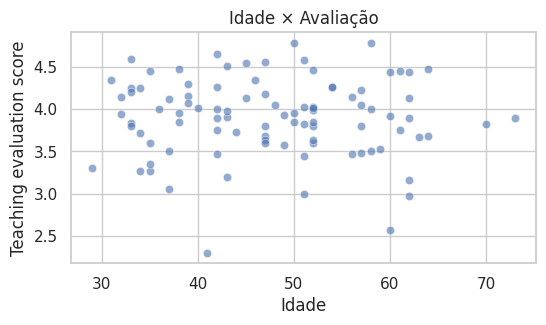

In [50]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "age": "first", "eval": "mean"}).reset_index()

plt.figure(figsize=(6, 3))
sns.scatterplot(x="age", y="eval", data=teach_df, alpha=0.6)
plt.title("Idade × Avaliação")
plt.xlabel("Idade")
plt.ylabel("Teaching evaluation score")
plt.show()

🟣 **Interpretação**
- Relação fraca.
- Avaliações são relativamente estáveis independentemente da idade.

# 🔵 8.7 Análise 5 — Idade × Avaliação por gênero

- Pergunta:
    > **A relação muda entre homens e mulheres?**

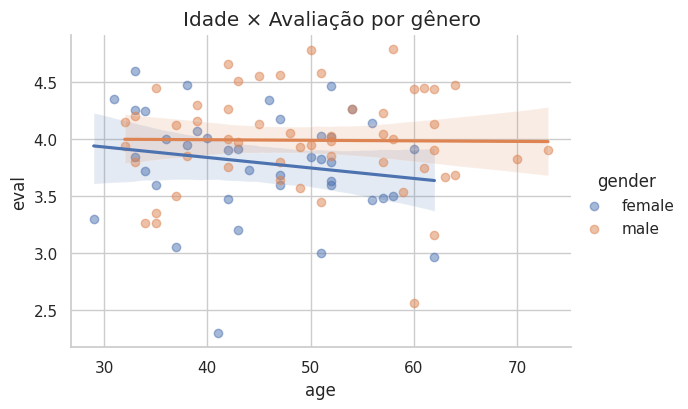

In [47]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "age": "first", "eval": "mean"}).reset_index()

sns.lmplot(x="age", y="eval", hue="gender", data=teach_df, height=4, aspect=1.5, scatter_kws={"alpha": 0.5})
plt.suptitle("Idade × Avaliação por gênero", y=1.02)
plt.show()

🟣 **Interpretação**
- Linhas quase paralelas.
- Relação semelhante entre gêneros.

🟣 **Storytelling**
- “Gênero não altera a relação idade × avaliação.”

# 🔵 8.8 Análise 6 — Beauty × Avaliação

- Pergunta:
    > **Instrutores mais “atrativos” recebem avaliações maiores?**

Essa é a pergunta central do artigo original de Hamermesh.

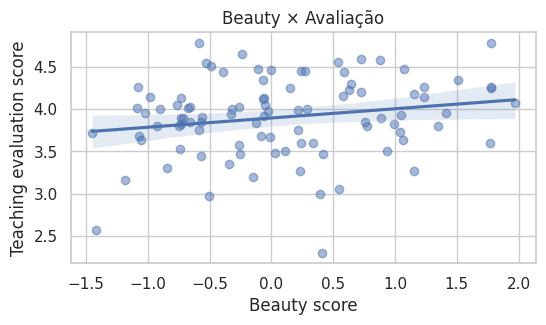

In [57]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "beauty": "first", "age": "first", "eval": "mean"}).reset_index()

plt.figure(figsize=(6, 3))
sns.regplot(x="beauty", y="eval", data=teach_df, scatter_kws={"alpha": 0.5})
plt.title("Beauty × Avaliação")
plt.xlabel("Beauty score")
plt.ylabel("Teaching evaluation score")
plt.show()

🟣 **Interpretação**
- Há uma leve tendência positiva.
- Instrutores com beauty score maior tendem a ter avaliações um pouco maiores.

🟣 **Storytelling**
- “A aparência tem um efeito pequeno, mas visível, nas avaliações.”

# 🔵 8.9 Análise 7 — Distribuição de beauty por gênero

- Pergunta:
    > **Homens e mulheres têm distribuições diferentes de beauty?**

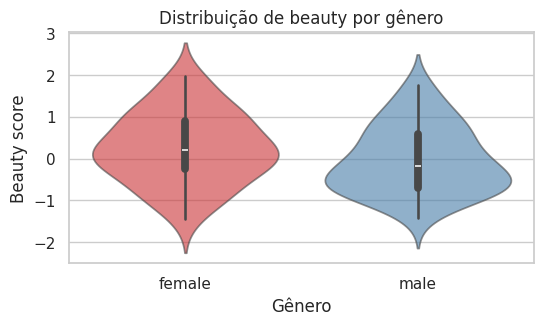

In [67]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "beauty": "first", "age": "first", "eval": "mean"}).reset_index()

plt.figure(figsize=(6, 3))
sns.violinplot(x="gender", y="beauty", hue="gender", data=teach_df, palette="Set1", alpha=0.6)
plt.title("Distribuição de beauty por gênero")
plt.xlabel("Gênero")
plt.ylabel("Beauty score")
plt.show()

🟣 **Interpretação**
- Distribuições semelhantes.
- Mulheres têm leve assimetria.

🟣 **Storytelling**
- “Beauty score é relativamente equilibrado entre gêneros.”

# 🔵 8.10 Análise 8 — Cursos por gênero × tenure × division

- Pergunta:
    > **Como gênero e tenure se distribuem dentro de cada divisão?**

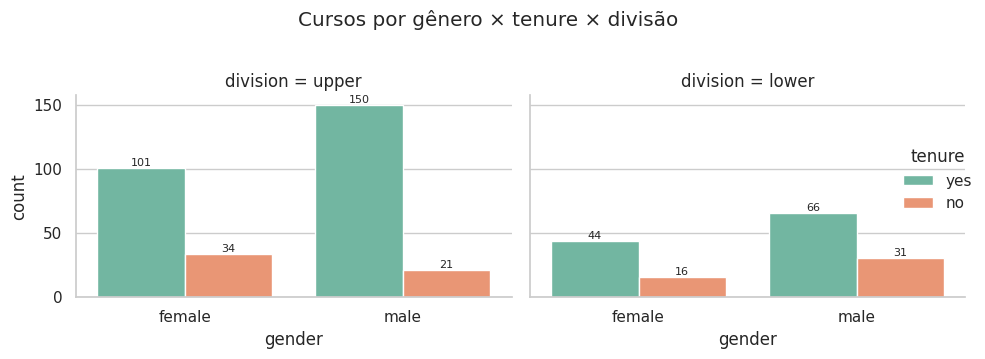

In [76]:
i = sns.catplot(x="gender", hue="tenure", col="division", kind="count", data=ratings_df, height=3.5, aspect=1.3, palette="Set2")
plt.suptitle("Cursos por gênero × tenure × divisão", y=1.02)
for ax in i.axes.flatten():
    for p in ax.containers:
        ax.bar_label(p, fontsize=8)
plt.tight_layout()
plt.show()

🟣 **Interpretação**
- Padrões diferentes entre upper e lower division.
- Homens têm maior proporção de tenure em ambas as divisões.

🟣 **Storytelling**
- “A distribuição de tenure por gênero é consistente entre divisões.”

# 🔵 8.11 Análise 9 — ECDF da avaliação

- Pergunta:
    > **Qual a probabilidade de um curso ter avaliação abaixo de x?**

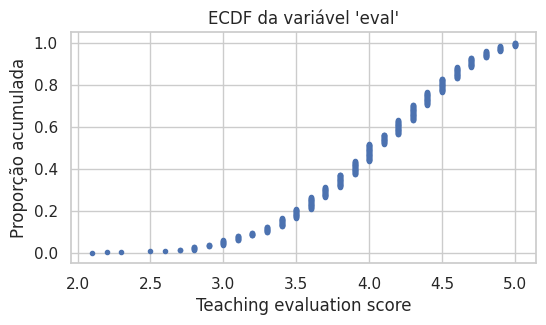

In [81]:
def ecdf(data):
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    return x, y

x, y = ecdf(ratings_df["eval"])

plt.figure(figsize=(6, 3))
plt.plot(x, y, marker=".", linestyle="none")
plt.title("ECDF da variável 'eval'")
plt.xlabel("Teaching evaluation score")
plt.ylabel("Proporção acumulada")
plt.show()

🟣 **Interpretação**
- 50% das avaliações estão abaixo de ~4.0.
- 90% estão acima de ~3.5.

🟣 **Storytelling**
- “Avaliações são consistentemente altas.”

# 🔵 8.12 Análise 10 — Pairplot completo

- Pergunta:
    > **Como idade, beleza e avaliação se relacionam simultaneamente?**

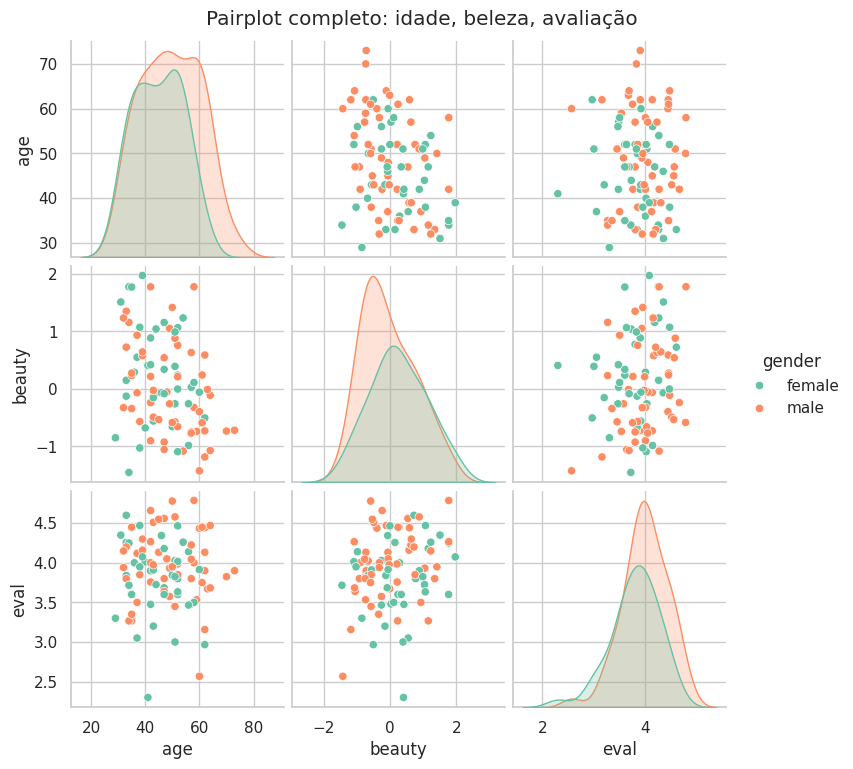

In [ ]:
teach_df = ratings_df.groupby("prof").agg({"gender": "first", "beauty": "first", "age": "first", "eval": "mean"}).reset_index()

sns.pairplot(
    teach_df[["age", "beauty", "eval", "gender"]],
    hue="gender",
    diag_kind="kde",
    palette="Set2"
)
plt.suptitle("Pairplot completo: idade, beleza, avaliação", y=1.02)
plt.show()

🟣 **Interpretação**
- Relações fracas entre variáveis numéricas.
- Beauty × eval tem leve tendência positiva.
- Idade × eval é quase aleatória.

🟣 **Storytelling**
- “Beauty tem efeito pequeno; idade não tem efeito visível.”

### 🟠 Conteúdo avançado (opcional) — análise multivariada

- Correlação parcial
    - Controla o efeito de outras variáveis.

- Regressão múltipla
    - Avaliação ~ idade + beauty + gênero + tenure

- Interações
    - Efeitos diferentes entre grupos.

- Visualização multivariada
    - FacetGrid
    - lmplot
    - pairplot

Visualização é o primeiro passo antes de modelar.

<br>

---

<a id="exercicios"></a>
[↑ - Índice](#indice)
# 9. Exercícios guiados


Esta seção contém exercícios práticos para consolidar:
- gráficos categóricos,
- gráficos numéricos,
- relações entre variáveis,
- storytelling visual,
- boas práticas de design.

Cada exercício inclui:
- enunciado,
- célula com `# TODO`,
- dicas,
- e, quando apropriado, perguntas interpretativas.

Use estes exercícios para:
- revisar o módulo,
- treinar para o exame final,
- desenvolver raciocínio estatístico e visual.

---
## 🟣 Exercício 1 — Histograma + KDE

**Tarefa:**  
Crie um histograma com KDE para a variável `age`.

**Perguntas para responder:**
- A distribuição é simétrica ou assimétrica?
- Há caudas longas?
- Há concentração em alguma faixa etária?

In [ ]:
# TODO: seu código aqui
# Dica: use sns.histplot(ratings_df["age"], kde=True)

---
## 🟣 Exercício 2 — Boxplot de avaliação por tenure

**Tarefa:**  
Crie um boxplot comparando `eval` entre instrutores com e sem tenure.

**Perguntas:**
- Há diferença nas medianas?
- Há outliers?
- A dispersão é semelhante?

In [ ]:
# TODO: seu código aqui
# Dica: use sns.boxplot(x="tenure", y="eval", data=ratings_df)

---
## 🟣 Exercício 3 — Violinplot de beauty por gender

**Tarefa:**  
Crie um violinplot para comparar a distribuição de `beauty` entre homens e mulheres.

**Perguntas:**
- As distribuições são semelhantes?
- Há assimetria?
- Há diferenças visíveis nas densidades?

In [ ]:
# TODO: seu código aqui
# Dica: use sns.violinplot(x="gender", y="beauty", data=ratings_df)

---
## 🟣 Exercício 4 — Scatterplot idade × avaliação

**Tarefa:**  
Crie um scatterplot mostrando a relação entre `age` e `eval`.

**Perguntas:**
- A relação parece linear?
- Há padrões visíveis?
- Há clusters?

In [ ]:
# TODO: seu código aqui
# Dica: use sns.scatterplot(x="age", y="eval", data=ratings_df)

---
## 🟣 Exercício 5 — Scatterplot com hue

**Tarefa:**  
Repita o exercício anterior, mas agora usando `gender` como `hue`.

**Perguntas:**
- A relação muda entre gêneros?
- Há diferenças de dispersão?

In [ ]:
# TODO: seu código aqui
# Dica: use hue="gender"

---
## 🟣 Exercício 6 — Regressão linear (regplot)

**Tarefa:**  
Crie um `regplot` para `beauty` × `eval`.

**Perguntas:**
- A tendência é positiva ou negativa?
- A linha de regressão é inclinada?
- A dispersão é grande?

In [ ]:
# TODO: seu código aqui
# Dica: use sns.regplot(x="beauty", y="eval", data=ratings_df)

---
## 🟣 Exercício 7 — Catplot multivariado

**Tarefa:**  
Crie um `catplot` mostrando a contagem de cursos por `gender` e `tenure`.

**Perguntas:**
- Há diferenças entre gêneros?
- Há padrões de tenure?

In [ ]:
# TODO: seu código aqui
# Dica: use sns.catplot(x="gender", hue="tenure", kind="count", data=ratings_df)

---
## 🟣 Exercício 8 — FacetGrid idade × avaliação

**Tarefa:**  
Crie um FacetGrid com:
- `row="tenure"`
- `col="gender"`

Mostrando a relação entre `age` e `eval`.

**Perguntas:**
- Há diferenças entre painéis?
- Algum grupo se destaca?

In [ ]:
# TODO: seu código aqui
# Dica: use sns.FacetGrid(...).map_dataframe(...)

---
## 🟣 Exercício 9 — ECDF da variável eval

**Tarefa:**  
Plote a ECDF de `eval` usando a função `ecdf()` definida anteriormente.

**Perguntas:**
- Qual é a mediana visual?
- Qual é o percentil 90?

In [ ]:
# TODO: seu código aqui
# Dica: use plt.plot(x, y, marker=".", linestyle="none")

---
## 🟣 Exercício 10 — Pairplot completo

**Tarefa:**  
Crie um pairplot com as variáveis:
- `age`
- `beauty`
- `eval`
- `gender`

**Perguntas:**
- Quais relações parecem mais fortes?
- Há clusters?
- Há assimetrias?

In [ ]:
# TODO: seu código aqui
# Dica: use sns.pairplot(..., hue="gender")

---
## 🟣 Exercício 11 — Storytelling visual

**Tarefa:**  
Escolha **qualquer relação** do dataset e crie:
- um gráfico,
- um título informativo,
- uma interpretação de 3 linhas.

**Objetivo:**  
Demonstrar sua capacidade de transformar dados em narrativa visual.

In [ ]:
# TODO: seu código aqui
# Dica: escolha qualquer variável e aplique storytelling

---
## 🟣 Exercício 12 — Desafio avançado (opcional)

**Tarefa:**  
Crie um gráfico que combine:
- uma variável numérica,
- uma variável categórica,
- uma terceira variável como `hue`,
- e facetamento (`row` ou `col`).

**Perguntas:**
- O que o gráfico revela?
- Há interações entre variáveis?
- Como você comunicaria isso em uma apresentação?

In [ ]:
# TODO: seu código aqui
# Dica: combine catplot, relplot ou FacetGrid

<br>

---

<a id="diagramas"></a>
[↑ - Índice](#indice)
# 10. Diagramas conceituais


Esta seção resume os principais conceitos do módulo em forma de:
- mapas mentais,
- diagramas hierárquicos,
- sínteses visuais,
- estruturas conceituais.

Esses diagramas são ideais para:
- revisão rápida,
- memorização,
- preparação para provas,
- organização mental do conteúdo.

## 🟣 10.1 Mapa mental — Tipos de gráficos

```text
Tipos de Gráficos
├── Comparação
│   ├── Barplot
│   ├── Countplot
│   ├── Column chart
│   └── Line chart (se houver tempo)
│
├── Composição
│   ├── Pie chart (poucas categorias)
│   ├── Stacked bar
│   └── Stacked area
│
├── Distribuição
│   ├── Histograma
│   ├── KDE
│   ├── Boxplot
│   ├── Violinplot
│   └── ECDF (avançado)
│
└── Relação
    ├── Scatterplot
    ├── Bubble chart
    ├── Regplot
    ├── Lmplot
    └── Pairplot
```

## 🟣 10.2 Mapa mental — Tipos de variáveis

```text
Tipos de Variáveis
├── Categóricas
│   ├── Nominais (gender, tenure)
│   └── Ordinais (níveis, categorias ordenadas)
│
├── Numéricas
│   ├── Contínuas (age, beauty)
│   └── Discretas (students)
│
└── Mistas
    ├── Categórica + Numérica
    └── Numérica + Numérica
```

## 🟣 10.3 Mapa mental — Storytelling com dados

```text
Storytelling com Dados
├── 1. Mensagem
│   ├── Qual pergunta estou respondendo?
│   └── Qual insight quero comunicar?
│
├── 2. Evidência
│   ├── Qual gráfico representa melhor a mensagem?
│   └── Quais dados sustentam o argumento?
│
└── 3. Design
    ├── Destaque o que importa
    ├── Remova ruído
    ├── Use cores com propósito
    ├── Títulos informativos
    └── Hierarquia visual
```

## 🟣 10.4 Mapa mental — Boas práticas de visualização

```text
Boas Práticas
├── Clareza
│   ├── Títulos informativos
│   ├── Eixos rotulados
│   └── Legendas claras
│
├── Consistência
│   ├── Mesmas cores para mesmas categorias
│   ├── Escalas iguais quando comparável
│   └── Estilo uniforme
│
├── Precisão
│   ├── Evitar 3D
│   ├── Evitar distorções
│   └── Evitar pie charts com muitas categorias
│
└── Estética
    ├── Paletas adequadas
    ├── Layout limpo
    └── Minimizar chartjunk
```

## 🟣 10.5 Mapa mental — Relações entre variáveis

```text
Relações Entre Variáveis
├── Numérica × Numérica
│   ├── Scatterplot
│   ├── Regplot
│   ├── Lmplot
│   └── Bubble chart
│
├── Numérica × Categórica
│   ├── Boxplot
│   ├── Violinplot
│   └── Swarmplot
│
└── Categórica × Categórica
    ├── Countplot
    ├── Stacked bar
    └── Heatmap de contingência
```

## 🟣 10.6 Mapa mental — Pipeline de análise visual

```text
Pipeline de Análise Visual
├── 1. Entender o problema
│   └── Qual pergunta quero responder?
│
├── 2. Explorar os dados
│   ├── Estrutura
│   ├── Tipos de variáveis
│   └── Estatísticas básicas
│
├── 3. Escolher o gráfico certo
│   ├── Comparação
│   ├── Composição
│   ├── Distribuição
│   └── Relação
│
├── 4. Criar o gráfico
│   ├── Cores
│   ├── Estilo
│   └── Layout
│
├── 5. Interpretar
│   ├── Tendências
│   ├── Outliers
│   └── Padrões
│
└── 6. Comunicar
    ├── Título informativo
    ├── Destaques
    └── Narrativa visual
```

## 🟣 10.7 Mapa mental — Erros comuns

```text
Erros Comuns
├── Pie charts com muitas categorias
├── Gráficos 3D
├── Escalas quebradas sem aviso
├── Cores aleatórias
├── Falta de rótulos
├── Bins ruins em histogramas
└── Excesso de informação (chartjunk)
```

## 🟣 10.8 Mapa mental — Paletas de cores

```text
Paletas de Cores
├── Qualitativas (categorias)
│   ├── Set2
│   ├── Paired
│   └── Accent
│
├── Sequenciais (intensidade)
│   ├── Blues
│   ├── Greens
│   └── Purples
│
└── Divergentes (acima/abaixo da média)
    ├── coolwarm
    ├── RdBu
    └── Spectral
```

## 🟣 10.9 Mapa mental — Quando usar cada gráfico

```text
Quando Usar Cada Gráfico
├── Barplot     → comparar médias entre grupos
├── Countplot   → comparar frequências
├── Histograma  → distribuição bruta
├── KDE         → distribuição suave
├── Boxplot     → mediana, quartis, outliers
├── Violinplot  → forma completa da distribuição
├── Scatterplot → relação entre variáveis numéricas
├── Regplot     → tendência linear
├── Lmplot      → regressão por grupos
├── Pairplot    → visão geral multivariada
└── FacetGrid   → comparações condicionais
```

<br>

---

<a id="apendice"></a>
[↑ - Índice](#indice)
# 11. Apêndice matemático avançado


- Este apêndice reúne fundamentos matemáticos e perceptuais que sustentam:
    - histogramas,
    - KDE,
    - ECDF,
    - regressão visual,
    - correlação,
    - percepção visual,
    - princípios de design estatístico.

- É conteúdo opcional, mas extremamente valioso para quem deseja:
    - aprofundar-se em estatística,
    - entender a teoria por trás dos gráficos,
    - interpretar visualizações com rigor científico.

## 🟠 11.1 Histograma — definição formal

O histograma é uma aproximação da densidade de probabilidade.

- Dado um conjunto de dados $x_1, x_2, \dots, x_n$ e bins $B_1, B_2, \dots, B_k$:  

    | $$ h_j = \frac{1}{n} \sum_{i=1}^n \mathbf{1}(x_i \in B_j) $$ |
    |-|


    - onde:
        - $h_j$ é a altura da barra,
        - $\mathbf{1}$ é a função indicadora.

- O histograma depende fortemente:
    - do número de bins,
    - da largura dos bins,
    - da posição dos bins.

Por isso, histogramas podem parecer diferentes para o mesmo conjunto de dados.

## 🟠 11.2 KDE — Kernel Density Estimation

A KDE é uma estimativa suave da densidade de probabilidade.

- Definição:  

    | $$ \hat{f}(x) = \frac{1}{nh} \sum_{i=1}^n K\left(\frac{x - X_i}{h}\right) $$ |
    |-|


    - onde:
        - $K$ é o kernel (Normal, Epanechnikov, Uniforme),
        - $h$ é o *bandwidth* (parâmetro de suavização).

- **Efeito do bandwidth**
    - **$h$ pequeno** → curva ruidosa (overfitting)  
    - **$h$ grande** → curva super-suavizada (underfitting)

- O seaborn escolhe automaticamente um $h$ razoável usando heurísticas como:
    - regra de Silverman,
    - regra de Scott.

## 🟠 11.3 ECDF — Empirical Cumulative Distribution Function

- A ECDF é definida como:  

    | $$ F_n(x) = \frac{1}{n} \sum_{i=1}^n \mathbf{1}(X_i \le x) $$ |
    |-|

<br>

- Propriedades:
    - sempre crescente,
    - converge para a CDF verdadeira (Lei dos Grandes Números),
    - não perde informação (diferente do histograma),
    - ideal para comparar distribuições.

## 🟠 11.4 Boxplot — quartis, IQR e outliers

- O boxplot é baseado em estatísticas robustas:
    - **Q1** = primeiro quartil (25%)  
    - **Q2** = mediana (50%)  
    - **Q3** = terceiro quartil (75%)  

- O intervalo interquartil (IQR):  

    | $$ IQR = Q3 - Q1 $$ |
    |-|

<br>

- Outliers são definidos como:  

    | $$ x < Q1 - 1.5 \cdot IQR \quad \text{ou} \quad x > Q3 + 1.5 \cdot IQR $$ |
    |-|

Essa regra é empírica, mas funciona bem na prática.

## 🟠 11.5 Correlação — Pearson e Spearman

- **Correlação de Pearson**

    - Mede relação **linear**:  

        | $$ r = \frac{\sum (x_i - \bar{x})(y_i - \bar{y})} {\sqrt{\sum (x_i - \bar{x})^2 \sum (y_i - \bar{y})^2}} $$ |
        |-|

        - Valores:
            - $r = 1$ → correlação perfeita positiva  
            - $r = -1$ → correlação perfeita negativa  
            - $r = 0$ → sem relação linear  

- **Correlação de Spearman**
    - Mede relação **monotônica**, usando ranks.

    - Útil quando:
        - há outliers,
        - a relação não é linear.

## 🟠 11.6 Regressão linear — interpretação visual

- A regressão linear simples:  

    | $$ y = \beta_0 + \beta_1 x + \varepsilon $$ |
    |-|

    - Onde:
        - $\beta_1$ → inclinação (tendência)  
        - $\beta_0$ → intercepto  
        - $\varepsilon$ → erro aleatório  

- **Interpretação visual**
    - inclinação → direção da relação  
    - dispersão → força da relação  
    - outliers → influência  

    - O `regplot` e o `lmplot` do seaborn mostram:
        - linha de tendência,
        - intervalo de confiança,
        - dispersão dos pontos.

## 🟠 11.7 Percepção visual — fundamentos formais

- A visualização funciona porque o cérebro humano é otimizado para:
    - detectar padrões,
    - comparar posições,
    - perceber diferenças relativas,
    - identificar tendências.

- **Lei de Weber–Fechner**
    - A percepção de diferença é proporcional ao logaritmo da intensidade.

- Isso explica por que:
    - barras são mais fáceis de comparar que áreas,
    - gráficos de pizza são difíceis de interpretar,
    - escalas logarítmicas são úteis para grandes variações.

- **Leis da Gestalt*
    - **Proximidade** → agrupamento  
    - **Similaridade** → categorias  
    - **Continuidade** → tendências  
    - **Fechamento** → completude  

Esses princípios fundamentam o design de gráficos eficazes.

## 🟠 11.8 Princípios de Tufte — fundamentos matemáticos

- Edward Tufte propôs princípios que podem ser formalizados:  

1. **Data-ink ratio**  

    | $$ \text{Data-ink ratio} = \frac{\text{tinta que representa dados}} {\text{tinta total usada no gráfico}} $$ |
    |-|

    - Objetivo:
        - maximizar a proporção de tinta que representa dados,
        - minimizar elementos decorativos.

2. **Chartjunk**
    - elementos visuais que não contribuem para a informação,
    - reduzem a eficiência perceptual.

3. **Small multiples**
    - comparar padrões usando painéis idênticos,
    - base matemática: escalas iguais → comparabilidade.

## 🟠 11.9 Kernel functions — detalhes matemáticos

**Kernels comuns na KDE:**

- **Kernel Gaussiano**  

    | $$ K(u) = \frac{1}{\sqrt{2\pi}} e^{-u^2/2} $$ |
    |-|

<br>

- **Kernel Epanechnikov**  

    | $$ K(u) = \frac{3}{4}(1 - u^2) \mathbf{1}(\|u\| \le 1) $$ |
    |-|

<br>

- **Kernel Uniforme**  

    | $$ K(u) = \frac{1}{2} \mathbf{1}(\|u\| \le 1) $$ |
    |---|


O kernel Gaussiano é o mais usado por ser suave e matematicamente conveniente.

## 🟠 11.10 Bandwidth selection — regra de Silverman

**A escolha do bandwidth $h$ é crítica.**

- A regra de Silverman:  

| $$ h = 0.9 \cdot \min(\sigma, \frac{IQR}{1.34}) \cdot n^{-1/5} $$ |
|-|

- onde:
    - $\sigma$ é o desvio padrão,
    - $IQR$ é o intervalo interquartil,
    - $n$ é o tamanho da amostra.

Essa regra equilibra suavização e precisão.

## 🟠 11.11 Conclusão do apêndice

- Este apêndice fornece a base teórica para:
    - interpretar gráficos com rigor,
    - entender limitações,
    - escolher métodos adequados,
    - comunicar resultados com precisão.

- Visualização é uma combinação de:
    - estatística,
    - matemática,
    - percepção humana,
    - design,
    - narrativa.

Dominar esses fundamentos transforma gráficos em **insights poderosos**.

<br>

---

<a id="12-encerramento"></a>
[↑ - Índice](#indice)
# 12. Encerramento


Parabéns por concluir o **Módulo 3 — Visualização de Dados**.

- Este módulo foi um dos mais importantes da formação, porque visualização é:
    - análise,
    - comunicação,
    - percepção,
    - design,
    - narrativa,
    - e ciência.

Você aprendeu não apenas a criar gráficos, mas a **pensar visualmente**.

Vamos revisar os principais aprendizados.

## 🔵 O que você aprendeu (conteúdo oficial)

- Criar gráficos básicos com seaborn e matplotlib.  
- Usar histogramas, boxplots, scatterplots e catplots.  
- Interpretar distribuições e relações entre variáveis.  
- Aplicar visualizações ao dataset *teachingratings*.  
- Entender quando usar cada tipo de gráfico.  

## 🟣 O que você aprendeu (conteúdo expandido — livro didático)

- Princípios de design de informação (Tufte, Few).  
- Percepção visual (Gestalt, pré-atentivo).  
- Storytelling com dados (mensagem → evidência → design).  
- Como transformar gráficos em narrativas claras.  
- Como escolher paletas, estilos e layouts.  
- Como evitar erros comuns e chartjunk.  
- Como comparar grupos, distribuições e relações multivariadas.  

## 🟠 O que você aprendeu (conteúdo avançado)

- Matemática da KDE, ECDF e histogramas.  
- Fundamentos formais de regressão visual.  
- Correlação de Pearson e Spearman.  
- Bandwidth selection (regra de Silverman).  
- Kernels (Gaussiano, Epanechnikov, Uniforme).  
- Princípios perceptuais formais (Weber–Fechner).  
- Estruturas avançadas de visualização (FacetGrid, Pairplot).  

---
# 🧠 Síntese final

- Visualização é a ponte entre:
    - **dados** e **insights**,  
    - **estatística** e **comunicação**,  
    - **análise** e **decisão**.

- Um gráfico bem construído:
    - revela padrões,
    - destaca o que importa,
    - reduz ruído,
    - guia o olhar,
    - conta uma história.

- Você agora domina:
    - os fundamentos,
    - as ferramentas,
    - as técnicas,
    - e a teoria necessária para criar visualizações profissionais.

---
# 🔗 Conexão com o Módulo 2 e o Módulo 4

### 🔵 Do Módulo 2 → para o Módulo 3
- No Módulo 2, você aprendeu:
    - estatística descritiva,
    - medidas de tendência central,
    - variabilidade,
    - distribuições.

No Módulo 3, você **visualizou** tudo isso.

- Visualização é a forma mais natural de:
    - entender distribuições,
    - comparar grupos,
    - detectar outliers,
    - explorar relações.

### 🔵 Do Módulo 3 → para o Módulo 4

- O Módulo 4 será sobre:
    - **probabilidade**,  
    - **inferência estatística**,  
    - **testes de hipótese**,  
    - **intervalos de confiança**,  
    - **modelos estatísticos**.

E adivinha?

- Visualização será essencial para:
    - entender distribuições teóricas,
    - comparar amostras,
    - visualizar incerteza,
    - interpretar resultados de modelos.

Você está preparado.

# 🚀 Próximos passos

- **Para consolidar o aprendizado:**

    - ✔️ **Refaça os exercícios guiados**  
        - Com foco em interpretação e storytelling.

    - ✔️ **Crie visualizações para datasets novos**  
        - Quanto mais prática, melhor.

    - ✔️ **Comece a pensar visualmente**  
        -   Antes de qualquer análise, pergunte:

            > “Qual gráfico responde essa pergunta?”

    - ✔️ **Use visualização para comunicar**  
        - Em relatórios, apresentações, dashboards.

---
# 🎉 Parabéns!

Você concluiu um dos módulos mais importantes da formação.

Agora você domina:
- visualização estatística,
- comunicação visual,
- storytelling com dados,
- e fundamentos matemáticos avançados.

Isso coloca você em um nível profissional de análise visual.

Nos vemos no **Módulo 4 — Probabilidade e Inferência Estatística**.